# Analyze Events

## Load Libraries

In [1]:
import matplotlib
import pandas as pd
import numpy as np
import matplotlib
from matplotlib import pyplot as plt 
from matplotlib import colors
import matplotlib.cm as cmx
from collections import defaultdict
from scipy.interpolate import interp1d,LinearNDInterpolator
import os

In [2]:
#load ML libraries
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, roc_curve, mean_squared_error
from sklearn.preprocessing import QuantileTransformer
from sklearn.pipeline import Pipeline

In [3]:
loadEverything = False   #Load all event files and recompute observables? If false, use previously produced observables file 
eventstag='events'       #Support detector length up to 80 cm

#The smallest z0 value expected to be found in the files, indicates the max detector depth to consider  
z0min=-80.

# Ensure output destination exists
if not os.path.exists('plots'): os.mkdir('plots')


## Load file and extract observables

In [4]:
checkpids={}  #For storing all pids found in the files
def calculate_observables(filename=eventstag+"/"+eventstag+"_CC_12_1000.csv.zip", debug=False):
    
    # load data
    data = pd.read_csv(filename)
    
    # group data
    grouped_data = data.groupby('ievent')
    
    # loop through data and calculate observables
    events = []
    for ievent, evt in grouped_data:
        
        # highest energy lepton information
        lep_pid, lep_e = 0, 0
        lep_theta = 0  #Leading lepton angle vs LOS
        lep_p3 = []  #For reconstructing leading lepton 3 momentum
        # highest energy electron and muon
        e_e,e_mu=0.,0.
        # total em energy
        e_em = 0
        # sum of charged particle energies
        e_ch = 0
        # sum of all particle energies
        e_tot = 0
        # sum of high-E electron charges
        chEM = 0
        # statistics of the angles of all EM particles vs leading e+/-
        em_p3 = []
        em_theta_std,em_theta_max = 0.,0.
        
        # not observables, but useful for checking the showering
        Ngamma = 0  #Number of photons
        NEM = 0     #Number of photons and e^+/-

        # Iterate over particles in the event
        if debug: print('')
        if debug: print('ievent '+str(ievent))
        for _, row in evt.iterrows():
            
            #get particle data
            truth_energy = row.iloc[2]  #In all iterations, this entry will be the initial neutrino truth energy
            pid, px, py, pz, e, = row.iloc[3], row.iloc[4], row.iloc[5], row.iloc[6], row.iloc[7]
            z0, weight = row.iloc[10], row.iloc[11] 

            #drop all particles with energies too low to be observed
            if pid!=22 and e<20.: continue  #Low-E photons OK
            
            #Let's just see what's in each line of an event
            if debug: print(truth_energy,pid,pz,e,z0,weight) 
              
            # total energy of all particles above 20 GeV, excluding neutrinos
            if abs(pid) not in [12, 14, 16]: e_tot += e
            
            # update shower check variables
            if pid==22: Ngamma += 1
            if pid in [22, 11, -11]: NEM += 1

            # update observables
            # find highest energy e^+/- or mu^+/-, store it's energy and PID
            if pid in [11,-11,13,-13]: 
                if e>lep_e: 
                    lep_e, lep_pid = e, pid
                    lep_p3 = [px, py, pz]
                    lep_theta = np.atan(np.sqrt(px**2+py**2)/pz)
            # find highest energy e^+/- and mu^+/-
            if   pid in [11,-11] and e>e_e : e_e  = e
            elif pid in [13,-13] and e>e_mu: e_mu = e
            # add all e^+/- and photon energies to total EM energy 
            if pid in [22, 11, -11]:
                e_em += e
                if np.linalg.norm([px, py, pz])>0: em_p3.append([px, py, pz])
            # sum charge of high-E electrons and positrons (EM particles)
            if pid in [11, -11] and e>100.: chEM += -1.*np.sign(pid)
            # total E of all particles that are not photons, neutral kaons, neutrons or neutrinos => total charged particle E
            # expect e,mu,pi+-,K+-,p+- contributions.
            if abs(pid) not in [22, 310, 130, 2112, 12, 14, 16]: e_ch += e
            #Store all pids into dict keys
            checkpids[int(pid)]=True
        
        if len(lep_p3)!=3 or np.linalg.norm(lep_p3)==0: continue  #Skip events w/o/ leading lepton

        # Statistical measures of EM particles's angles vs leading lepton
        if len(em_p3)!=0:  #If no EM particles found, return angle statistics as init 0 i.e. no angles for no particles
            coss = [np.dot(p3,lep_p3)/np.linalg.norm(p3)/np.linalg.norm(lep_p3) for p3 in em_p3]
            acoss = np.acos(np.clip(coss,-1,1))  #Numerics may cause 1.0000000000000002, clip handles them
            em_theta_std, em_theta_max = np.std(acoss), np.max(acoss)
        
        # Append event observables
        events.append([ievent,weight,truth_energy,lep_e,lep_pid,lep_theta,\
                       em_theta_std,em_theta_max,\
                       e_em,e_ch,e_tot,z0,e_e,e_mu,Ngamma,NEM,chEM])
    
    # Construct DataFrame from results
    columns = ['ievent','weight','truth_energy','lep_e','lep_pid','lep_theta',\
               'em_theta_std','em_theta_max',\
               'e_em','e_ch','e_tot','z0','e_e','e_mu','Ngamma','NEM','chEM']
    observables = pd.DataFrame(events, columns=columns)
    
    return observables


## Load Everything and Calculate Observables

In [5]:
def load_everything(debug=False,eventstag='events',mode='observables'):
    
    #get energies
    energies, _, _= np.loadtxt("fluxes/flux_FASER2_12.txt").T

    #SPecify neutrino flavors and processes to consider, depending on run mode
    vpids = ["14","-14", "12", "-12"]
    procs = ['CC', 'NC']

    #loop over datasets 
    all_data = None
    for vpid in vpids:
        for process in procs:
            for energy in energies: 

                # get all files and loop over them
                filename = eventstag+"/"+eventstag+"_"+process+"_"+vpid+"_"+str(energy)+".csv.zip"
                if debug: print ("load "+filename)
        
                # get observables
                observables = calculate_observables(filename=filename)
                observables['vpid']=vpid
                observables['process']=process
                
                # combine data
                if all_data is None and not observables.empty: all_data = observables
                elif not observables.empty: all_data = pd.concat([all_data, observables])
    
    #drop index
    all_data = all_data.reset_index(drop=True)
    
    # Export
    csv_file = eventstag+"/"+mode+".csv.zip"
    all_data.to_csv(csv_file, index=False, compression='zip')
    print("Saved "+mode+" to file: "+csv_file)

In [6]:
if loadEverything:
    load_everything(debug=True,eventstag=eventstag)
    print('All pids in the files:',list(checkpids.keys()))

### Check showering: should find more photons at lower energies and higher $|z_o|$

In [7]:
#Only retain nu_e CC events in the dataframe used exclusively for shower checks (no further analysis)
sc = pd.read_csv(eventstag+"/observables.csv.zip")
sc = sc[sc['vpid'].isin([12,-12])]
sc = sc[sc['process'].isin(['CC'])]
print(sc)

        ievent    weight  truth_energy        lep_e  lep_pid  lep_theta  \
149121      25  0.050424        28.371    24.342084     11.0   0.018988   
149122      39  0.050424        28.371    20.089013     11.0   0.037197   
149123      13  0.050152        35.717    21.910352     11.0   0.026185   
149124      15  0.050152        35.717    22.746647     11.0   0.021969   
149125      17  0.050152        35.717    20.720000     11.0   0.095146   
...        ...       ...           ...          ...      ...        ...   
172819       4  0.053556      3571.675   467.262870    -11.0   0.000919   
172820       5  0.053556      3571.675  1228.666047    -11.0   0.001843   
172821       6  0.053556      3571.675  1774.832719    -11.0   0.000703   
172822       7  0.053556      3571.675   861.752041    -11.0   0.015627   
172823       8  0.053556      3571.675   893.590011    -11.0   0.006605   

        em_theta_std  em_theta_max         e_em         e_ch        e_tot  \
149121      0.000330  

In [8]:
def z0avg(data,z0bins,obs):
    avg=[]
    for i in range(len(z0bins)-1):
        datatmp = data[data['z0']<z0bins[i]+1]
        datatmp = datatmp[datatmp['z0']>z0bins[i]]
        try: avg.append(sum(datatmp[obs]*datatmp['weight'])/sum(datatmp['weight']))
        except: avg.append(0)
    return avg

(-80.0, 0.0)

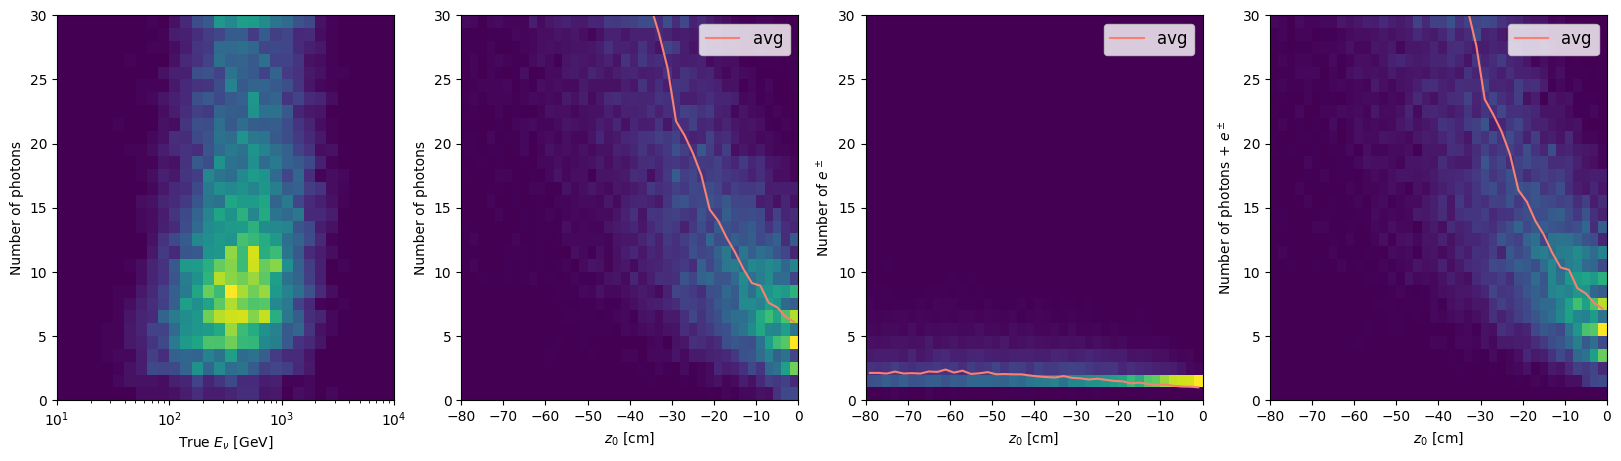

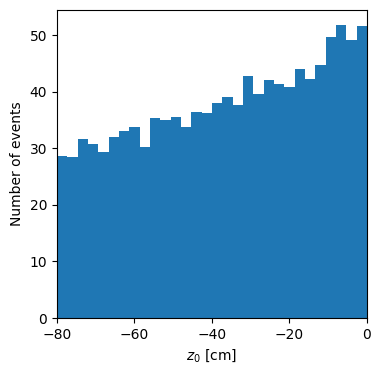

In [9]:
ebins_default = np.logspace(1,4,31)  #Will yield the flux energy values as bin centers

#Setup figure
matplotlib.rcParams.update({'font.size': 10})
matplotlib.rcParams['text.usetex'] = False
Nplots=4
fig = plt.figure(figsize=(5*Nplots,5))

#Plot average numbers of photons in some bins of z0
Ngammabins = np.linspace(0,30,31)
#z0bins_default = np.linspace(z0min,0,41)
z0bins_default = [n*z0min/40 for n in range(41)][::-1]
z0centers = np.multiply(0.5,np.add(z0bins_default[:-1],z0bins_default[1:]))

#plot scatterplot of predicted numbers of photons vs truth energy
ax = plt.subplot(1,Nplots,1)   
#ax.plot(sc['truth_energy'],sc['Ngamma'],linewidth=0,marker='.',markersize=0.5)
ax.hist2d(sc['truth_energy'],sc['Ngamma'],weights=sc['weight'],bins=(ebins_default,Ngammabins))
ax.set_xscale("log")
ax.set_xlabel(r'True $E_\nu$ [GeV]')
ax.set_ylabel(r'Number of photons')

# predicted numbers of photons vs z0
ax = plt.subplot(1,Nplots,2)   
#ax.plot(sc['z0'],sc['Ngamma'],linewidth=0,marker='.',markersize=0.5)
ax.hist2d(sc['z0'],sc['Ngamma'],weights=sc['weight'],bins=(z0bins_default,Ngammabins))
ax.set_xlabel(r'$z_0$ [cm]')
ax.set_ylabel(r'Number of photons')
ax.plot(z0centers,z0avg(data=sc,z0bins=z0bins_default,obs='Ngamma'),color='salmon',label='avg')
ax.legend(frameon=True, labelspacing=0, fontsize=12)

# predicted numbers of electrons and positrons vs z0
ax = plt.subplot(1,Nplots,3)   
ax.hist2d(sc['z0'],np.subtract(sc['NEM'],sc['Ngamma']),weights=sc['weight'],bins=(z0bins_default,Ngammabins))
ax.plot(z0centers,np.subtract(z0avg(data=sc,z0bins=z0bins_default,obs='NEM'),
                              z0avg(data=sc,z0bins=z0bins_default,obs='Ngamma')),
        color='salmon',label='avg')
ax.set_xlabel(r'$z_0$ [cm]')
ax.set_ylabel(r'Number of $e^\pm$')
ax.legend(frameon=True, labelspacing=0, fontsize=12)

# predicted numbers of EM particles (gamma+e^+/-) vs z0
ax = plt.subplot(1,Nplots,4)
ax.hist2d(sc['z0'],sc['NEM'],weights=sc['weight'],bins=(z0bins_default,Ngammabins))
ax.plot(z0centers,z0avg(data=sc,z0bins=z0bins_default,obs='NEM'),color='salmon',label='avg')
ax.set_xlabel(r'$z_0$ [cm]')
ax.set_ylabel(r'Number of photons + $e^\pm$')
ax.legend(frameon=True, labelspacing=0, fontsize=12)

# Check initial z0 - expect flat uniform distribution
fig = plt.figure(figsize=(4,4))
plt.hist(sc['z0'],weights=sc['weight'],bins=30)
plt.xlabel(r'$z_0$ [cm]')
plt.ylabel(r'Number of events')
plt.xlim(z0min,0)

### Functions to find and report signal purity, charge identification and efficiency

First let's define an aux function to plot the efficiencies etc as a function of energy for different detector lengths.

Param:
- `iplot`    Plot index for selecting correct subplot axes
- `ipdict`   The interpolation function dictionary for efficiency functions
- `title`    Plot title
- `effmode`  Key in `ipdict`: which efficiency function to plot, e.g. purity 'pur', efficiency 'eff',... 
- `Nrows`    Number of rows to plot figures on the canvas
- `Ncols`    Number of columns per row
- `ebins`    Energy observable bins
- `zbins`    Bins for the distance from the end of the detector

In [10]:
def efficiency_subplots(iplot,ipdict,title,effmode,Nrows,Ncols,ebins,zbins):

    if effmode not in ipdict: return iplot  #Cannot plot, do not advance index

    #Bins and grids
    ecenters = (ebins[:-1] + ebins[1:])/2
    zcenters = (zbins[:-1] + zbins[1:])/2
    egrid,zgrid = np.meshgrid(ecenters,zcenters)
    egrid,zgrid = egrid.flatten(),zgrid.flatten()

    #Basic setup
    cm = plt.get_cmap('turbo')
    cNorm  = colors.Normalize(vmin=0, vmax=len(zcenters)-1)
    scalarMap = cmx.ScalarMappable(norm=cNorm, cmap=cm)
    plotcontours = {0.5: 'salmon', 0.9: 'red'}

    #2D heatmap
    ax = plt.subplot(Nrows,Ncols,iplot)
    ax.set_title(title)
    ax.hist2d(egrid,zgrid,weights=ipdict[effmode](egrid,zgrid),bins=(ebins,zbins),cmap='bone')
    ax.contour(ecenters,zcenters,\
               [[ipdict[effmode](efval,zfval) for efval in ecenters] for zfval in zcenters],\
               levels=plotcontours.keys(), colors=plotcontours.values())
    for contour in plotcontours: ax.plot([10],[10],color=plotcontours[contour],label=str(contour*100)+'%')

    #1D functions
    ax = plt.subplot(Nrows,Ncols,Ncols+iplot)
    ax.set_ylabel(title)
    for iz,zfval in enumerate(zcenters):
        if zfval>-9: continue  #Detectors thinner than 10 cm not really considered
        ax.plot(ecenters,[ipdict[effmode](efval,zfval) for efval in ecenters],color=scalarMap.to_rgba(iz),linewidth=0.1)
        if iz%4==0: ax.plot([-1],[-1],color=scalarMap.to_rgba(iz),label=str(int(zfval))+' cm')
    ax.plot([ecenters[0],ecenters[-1]],[0.9,0.9],color='black',linestyle='dotted',linewidth=0.2)

    #Return increased index for next plot panel
    return iplot+1

In [11]:
def efficiency_plots(ipdict,eobs,ebins,zbins):
    
    #Initialize figure
    Nrows,Ncols = 2,len(list(ipdict.keys()))
    matplotlib.rcParams.update({'font.size': 12})
    fig = plt.figure(figsize=(4*Ncols,4*Nrows))
    
    #Purity
    iplot=efficiency_subplots(iplot=1,ipdict=ipdict,title=r'Purity $P$',effmode='pur',\
                              Nrows=Nrows,Ncols=Ncols,ebins=ebins,zbins=zbins)
    
    #Charge identification
    iplot=efficiency_subplots(iplot=iplot,ipdict=ipdict,title=r'CID $M$',effmode='cid',\
                              Nrows=Nrows,Ncols=Ncols,ebins=ebins,zbins=zbins)
    
    #Efficiency (previously survival rate)
    iplot=efficiency_subplots(iplot=iplot,ipdict=ipdict,title=r'Efficiency $\epsilon$',effmode='eff',\
                              Nrows=Nrows,Ncols=Ncols,ebins=ebins,zbins=zbins)

    #Total effect of all factors (previously efficiency)
    iplot=efficiency_subplots(iplot=iplot,ipdict=ipdict,title=r'$\epsilon \times P \times M$',effmode='tot',\
                              Nrows=Nrows,Ncols=Ncols,ebins=ebins,zbins=zbins)

    #Style setup
    for iax in range(Nrows*Ncols): 
        ax = plt.subplot(Nrows,Ncols,iax+1)   
        ax.set_xscale("log")
        if eobs=='e_e': ax.set_xlim(20,3000)
        else:           ax.set_xlim(20,5000)
        ax.set_xlabel(eobs)
        if iax+1 <= Ncols:
            ax.set_ylabel(r'Detector depth')
            ax.set_ylim(zbins[0],-10.)  #Detector sizes below 10<cm not interesting
        else:
            ax.set_ylim(0,1.05)            
        ax.legend(frameon=False, labelspacing=0, fontsize=12)
        plt.subplots_adjust(hspace=0.3,wspace=0.3)    #Adjust margins to fit axis labels and titles

The function to find the purity, charge identification, and efficiency interpolation functions.

Param
- `data`    The data object to be plotted
- `uncut`   Optional. If given, check the number of signal events before cuts etc. to report signal loss
- `ebins`   The energy bins
- `z0bins`  Detector depth coordinate binning to consider. 
- `eobs`    Which (energy) observable to consider? E.g. `'e_e'` for observed lepton or `'truth_energy'` for initial neutrino energy.
- `plots`   Flag to enable or disable plotting the computed factors vs energy
- `cumul`   Find cumulative efficiencies, i.e. each z value corresponds to a detector of that depth instead of a slice at that z value.

Returns a dictionary of interpolation functions, giving the signal purity, charge identification and efficiency as a function of the specified (energy) observable. Note that longer detectors will have lower efficiency. Therefore the resulting functions will take two input parameters: the total detector length and energy.

In [12]:
#Use coarser energy bins for efficiencies to avoid interpolation function fluctuations
ebins_efficiency = np.logspace(1,4,11)
def efficiency(data,uncut=pd.DataFrame(),ebins=ebins_efficiency,z0bins=np.linspace(z0min,0,20),eobs='truth_energy',plots=True,cumul=False):
    
    ecenters  = np.multiply(0.5,np.add(ebins[ 1:],ebins[ :-1]))
    z0centers = np.multiply(0.5,np.add(z0bins[1:],z0bins[:-1]))
    P_E_z,cid_E_z,eff_E_z,tot_E_z=[],[],[],[]  #For storing results eventually used as interpolation grids

    #If called for a BDT, we need to look at what set did the BDT classify the event as, not what the truth level set label was.
    predset,trueset = 'set','set'
    MLmode = 'pred_set' in list(data.keys())
    if MLmode: predset='pred_set'
    
    for iz0 in range(len(z0centers)):

        #Restrict detector length
        cut_sbg = data[data['z0']>z0bins[iz0]]  #Signal and background surviving cuts
        if not cumul: cut_sbg = cut_sbg[cut_sbg['z0']<z0bins[iz0+1]]
        if not uncut.empty:  #Signal and background before cuts
            all_sbg = uncut[uncut['z0']>z0bins[iz0]]
            if not cumul: all_sbg = all_sbg[all_sbg['z0']<z0bins[iz0+1]]
        
        #Signal events surviving cuts ("cut") - "nue" for nu_e events, "nub" for nuebar events, "sig" for nue+nub i.e. both signal events
        #In the ML analysis case, distinguish between cases where the true set is nue/nuebar vs cases where that was predicted 
        cut_nue_true = cut_sbg[cut_sbg[trueset].isin(['nue'   ])]  #Signal events with true incoming nue
        cut_nub_true = cut_sbg[cut_sbg[trueset].isin(['nuebar'])]  #                -||-             nuebar
        cut_nue_pred = cut_sbg[cut_sbg[predset].isin(['nue'   ])]  #Events classified as having incoming nue
        cut_nub_pred = cut_sbg[cut_sbg[predset].isin(['nuebar'])]  #                -||-                 nuebar

        #Prediction dataframes limited to events where the prediction was correct
        cut_nue_pred_true = cut_nue_pred[cut_nue_pred[trueset].isin(['nue'   ])]
        cut_nub_pred_true = cut_nub_pred[cut_nub_pred[trueset].isin(['nuebar'])]
        
        #Signal events before cuts ("all")
        if not uncut.empty: 
            all_nue = all_sbg[all_sbg[trueset].isin(['nue'])]
            all_nub = all_sbg[all_sbg[trueset].isin(['nuebar'])]
        
        #Histograms of event counts
        cut_sbg_Ehist,_ = np.histogram(cut_sbg[eobs],bins=ebins,weights=cut_sbg['weight'])
        if not uncut.empty:
            all_nue_Ehist,_ = np.histogram(all_nue[eobs],bins=ebins,weights=all_nue['weight'])
            all_nub_Ehist,_ = np.histogram(all_nub[eobs],bins=ebins,weights=all_nub['weight'])
            all_sig_Ehist   = np.add(all_nue_Ehist, all_nub_Ehist)
        #Predicted signal events
        cut_nue_pred_Ehist,_ = np.histogram(cut_nue_pred[eobs],bins=ebins,weights=cut_nue_pred['weight'])
        cut_nub_pred_Ehist,_ = np.histogram(cut_nub_pred[eobs],bins=ebins,weights=cut_nub_pred['weight'])
        cut_sig_pred_Ehist   = np.add(cut_nue_pred_Ehist, cut_nub_pred_Ehist)
        #Truth level
        cut_nue_true_Ehist,_ = np.histogram(cut_nue_true[eobs],bins=ebins,weights=cut_nue_true['weight'])
        cut_nub_true_Ehist,_ = np.histogram(cut_nub_true[eobs],bins=ebins,weights=cut_nub_true['weight'])
        cut_sig_true_Ehist   = np.add(cut_nue_true_Ehist, cut_nub_true_Ehist)
        #Correct predictions
        cut_nue_pred_true_Ehist,_ = np.histogram(cut_nue_pred_true[eobs],bins=ebins,weights=cut_nue_pred_true['weight'])
        cut_nub_pred_true_Ehist,_ = np.histogram(cut_nub_pred_true[eobs],bins=ebins,weights=cut_nub_pred_true['weight'])
        cut_sig_pred_true_Ehist   = np.add(cut_nue_pred_true_Ehist, cut_nub_pred_true_Ehist)

        #Helpful vector of zeroes/ones, in the shape of the histos vs E. 0 (1) At low (high) E, as the limit values of the efficiencies
        EhistShape = np.zeros(cut_sbg_Ehist.shape)
        #for i in range(1,int(len(EhistShape)/2)): EhistShape[-i]=1.
        
        #Signal purity
        if MLmode:
            P_E_z.append(np.clip(np.divide(cut_sig_pred_true_Ehist,cut_sig_pred_Ehist,out=EhistShape,where=cut_sig_pred_Ehist!=0),0,1))
        else:
            P_E_z.append(np.clip(np.divide(cut_sig_true_Ehist,cut_sbg_Ehist,out=EhistShape,where=cut_sbg_Ehist!=0),0,1))
        #for i in range(len(ebins)-1):
        #    if ebins[i]>1000 and np.isclose(P_E_z[-1][i],0.): P_E_z[-1][i]==1.  #Set no-event high-E bins to 1
        
        #Charge identification
        #Could also have different efficiencies for observed nue,nuebar, but combine into global CID factor for simplicity
        if MLmode:
            mis_nue = cut_nub_true[cut_nub_true[predset].isin(['nue'])]     #nuebarCC events but e^- observed => mistaken as nueCC
            mis_nub = cut_nue_true[cut_nue_true[predset].isin(['nuebar'])]  #  nueCC  events but e^+ observed => mistaken as nuebarCC
        else:
            mis_nue = cut_nub_true[cut_nub_true['lep_pid']== 11]  #nuebarCC events but e^- observed => mistaken as nueCC
            mis_nub = cut_nue_true[cut_nue_true['lep_pid']==-11]  #  nueCC  events but e^+ observed => mistaken as nuebarCC
        mis_nue_Ehist,_ = np.histogram(mis_nue[eobs],bins=ebins,weights=mis_nue['weight'])
        mis_nub_Ehist,_ = np.histogram(mis_nub[eobs],bins=ebins,weights=mis_nub['weight'])
        mis_sig_Ehist   = np.add(mis_nue_Ehist,mis_nub_Ehist)            #Now in the form mistakes/all...
        cid_sig_Ehist   = np.subtract(cut_sig_true_Ehist,mis_sig_Ehist)  #...turn into (1-mistakes/all)
        cid_E_z.append(np.clip(np.divide(cid_sig_Ehist,cut_sig_true_Ehist,out=EhistShape,where=cut_sig_true_Ehist!=0),0,1))
        
        #Efficiency rate
        if uncut.empty: eff_E_z.append(np.ones(EhistShape.shape))  #If efficiency cannot be computed 
        else:
            #Here we are not concerned with mislabeling, but with how many signal events are lost at truth level,
            #limiting performance even if the signal purity of all surviving events was 100%
            #Total ratio is the product of the nue & nuebar efficiencies, cuts removing all nuebar are no good even if all nue preserved
            eff_nue_Ehist = np.divide(cut_nue_true_Ehist,all_nue_Ehist,out=EhistShape,where=all_nue_Ehist!=0)
            eff_nub_Ehist = np.divide(cut_nub_true_Ehist,all_nub_Ehist,out=EhistShape,where=all_nub_Ehist!=0)
            eff_E_z.append(np.clip(np.multiply(eff_nue_Ehist,eff_nub_Ehist),0,1))
        
        #Total effect of all factors 
        tot_E_z.append(np.multiply(np.multiply(eff_E_z[-1],P_E_z[-1]),cid_E_z[-1]))

    #If only one bin was given, duplicate center point to correspond to bin start/end, necessary for IP function
    if len(ecenters)==1:
        ecenters = np.append(ecenters,ecenters[0])
        for i in range(len(z0centers)):
            P_E_z.append(P_E_z[0])
            cid_E_z.append(cid_E_z[0])
            if not uncut.empty: 
                eff_E_z.append(eff_E_z[0])
                tot_E_z.append(tot_E_z[0])
    if len(z0centers)==1:
        z0centers = np.append(z0centers,z0centers[0])
        P_E_z.append(P_E_z[0])
        cid_E_z.append(cid_E_z[0])
        if not uncut.empty: 
            eff_E_z.append(eff_E_z[0])
            tot_E_z.append(tot_E_z[0])
        
    #Provide flat arrays for LinearNDInterpolator
    egrid,z0grid = np.meshgrid(ecenters,z0centers)
    egrid,z0grid = egrid.flatten(), z0grid.flatten()
    P_E_z   = np.array(P_E_z  ).flatten()
    cid_E_z = np.array(cid_E_z).flatten()
    if not uncut.empty: 
        eff_E_z = np.array(eff_E_z).flatten()
        tot_E_z = np.array(tot_E_z).flatten()
    
    #return a dictionary with interpolation/extrapolation functions for purity, misidentification and efficiency at any energy
    ipdict={}
    ipdict['pur'] = LinearNDInterpolator(list(zip(egrid,z0grid)),P_E_z,  fill_value=1)
    ipdict['cid'] = LinearNDInterpolator(list(zip(egrid,z0grid)),cid_E_z,fill_value=1)
    if not uncut.empty: 
        ipdict['eff'] = LinearNDInterpolator(list(zip(egrid,z0grid)),eff_E_z,fill_value=1)
        ipdict['tot'] = LinearNDInterpolator(list(zip(egrid,z0grid)),tot_E_z,fill_value=1)

    if plots: efficiency_plots(ipdict=ipdict,eobs=eobs,ebins=ebins,zbins=z0bins)
    
    return ipdict

## Function to plot Stacked Histograms

The following function is a useful tool to quickly plot some histograms.
Produces two plots, one with linear and one with logarithmic vertical axis.

Param
- `data`        The data object to be plotted
- `observable`  The observable to plot, as a string
- `bins`        Binning for the histogram to be produced
- `xlabel`      Label string for the horizontal axis
- `title`       Title string to be added on top of the plot
- `xlog`        Bool, used logarithmic horizontal axis?
- `yspread`     For determining the range to be shown on the vertical axis of the logarithmic plot.

In [13]:
def get_stacked_histogram(
        data, 
        observable, 
        bins, 
        xlabel,
        title="",
        xlog=False, 
        yspread=1e3,
    ):
               
    # setup figure
    datasets = {'nue':"red", 'nuebar':"salmon", 'numu':"dodgerblue", 'NC':"limegreen"}
    labels = {'nue':r"CC $\nu_e$", 'nuebar':r"CC $\overline{\nu}_e$", 'numu':r"CC $\nu_\mu$", 'NC':r"NC"}
    
    matplotlib.rcParams.update({'font.size': 14})
    matplotlib.rcParams['text.usetex'] = False
    fig = plt.figure(figsize=(12,4.5))
    
    #plot processes 
    ax1 = plt.subplot(1,2,1)   
    ax2 = plt.subplot(1,2,2)   
    used_sets = []
    for idata, dataset in enumerate(datasets.keys()):
        
        #get stuff
        used_sets.append(dataset)
        subset = data[data['set'].isin(used_sets)]
        x, w = subset[observable], subset['weight']
        c, l = datasets[dataset], labels[dataset]
        
        # linear y-axis   
        ax1.hist(x, weights=w, histtype='bar', stacked=True, bins=bins, color=c, label = l,zorder=-idata)
        
        # log y axis
        ax2.hist(x, weights=w, histtype='bar', stacked=True, bins=bins, color=c, label = l,zorder=-idata)
    
    # linear y-axis           
    if xlog: ax1.set_xscale("log")
    ax1.set_xlabel(xlabel)
    ax1.set_title(title)
    ax1.set_ylabel(r"Interacting Neutrinos")
    ax1.legend(frameon=False, labelspacing=0, fontsize=12)
          
    # log y axis     
    if xlog: ax2.set_xscale("log")
    ax2.set_yscale("log")
    ax2.set_xlabel(xlabel)
    ax2.set_title(title)
    ax2.set_ylim(ax2.get_ylim()[1]/yspread, ax2.get_ylim()[1])
    ax2.set_ylabel(r"Interacting Neutrinos")
    ax2.legend(frameon=False, labelspacing=0, fontsize=12)
         
    #finalize
    plt.tight_layout()
    plt.show()

## Function to plot 2D Histograms

Param:
- `data0`          The signal
- `data1`          The background
- `binsx,binsy`    The (lower limit, upper limit, number of bins) for the horizontal/vertical axes
- `varx,vary`      The horizontal/vertical axis labels
- `coupling`       Redundant, see `coupling0`, `coupling1` below
- `lines`          Additional lines to be added on the plot
- `logx,logy`      Use logarithmic axes?
- `labelx,labely`  Labels for the axes
- `coupling0`      Rescale `data0` weights by `coupling0**2`
- `coupling1`      Rescale `data1` weights by `coupling1**2`
- `zlims`          Lower/upper limits for the values represented by colors in the 2D histo 
- `ylabelpad`      Labelpad object

In [14]:
def plot_2d(
        data0,
        data1,
        varx='e_mu_plus',
        vary='e_visible',
        binsx = [1,4,30],
        binsy = [1,4,30],
        label0 = 'Background',
        label1 = 'Signal',
        coupling = 1,
        lines=[],
        logx=True,
        logy=True,
        labelx=None,
        labely=None,
        coupling0=1,
        coupling1=1,
        zlims=[None,None],
        ylabelpad=None,
    ):
   
    #labels
    if labelx == None: labelx=varx
    if labely == None: labely=vary
        
    # remove 0s
    data0 = data0[(data0[varx]>0) & (data0[vary]>0) ].copy()
    data1 = data1[(data1[varx]>0) & (data1[vary]>0) ].copy()
       
    # log ticks and edges
    ticks = np.array([[np.linspace(10**(j),10**(j+1),9)] for j in range(-7,6)]).flatten()
    ticks = [np.log10(x) for x in ticks]
    ticklabels = np.array([[r"$10^{"+str(j)+"}$","","","","","","","",""] for j in range(-7,6)]).flatten()
    
    xmin, xmax, xnum = binsx[0], binsx[1], binsx[2]+1
    ymin, ymax, ynum = binsy[0], binsy[1], binsy[2]+1
    x_edges = np.linspace(xmin, xmax, num=xnum+1)
    y_edges = np.linspace(ymin, ymax, num=ynum+1)
    x_centers = 0.5*(x_edges[1:]+ x_edges[:-1])
    y_centers = 0.5*(y_edges[1:]+ y_edges[:-1])
    
    #initialize figure
    matplotlib.rcParams.update({'font.size': 15})
    fig = plt.figure(figsize=(18,5))
   
    #----------
    # signal 
    ax = plt.subplot(1,3,1)
    xvals = np.log10(data0[varx]) if logx else data0[varx] 
    yvals = np.log10(data0[vary]) if logy else data0[vary] 
    wvals = data0['weight']*coupling0**2
    #hist2d
    h0=ax.hist2d(x=xvals,y=yvals,weights=wvals,
            bins=[xnum,ynum],range=[[xmin,xmax],[ymin,ymax]],
            norm=matplotlib.colors.LogNorm(vmin=zlims[0], vmax=zlims[1]), cmap="rainbow",
    )
    fig.colorbar(h0[3], ax=ax, pad=0.02)
    # add line 
    for line in lines:
        xline = np.log10(line[0]) if logx else line[0]
        yline = np.log10(line[1]) if logy else line[0]
        ax.plot(xline,yline,c='k',ls='dashed',lw=3)
    #finish
    ax.set_title(label0)
    ax.set_xlabel(labelx)
    ax.set_ylabel(labely,labelpad=ylabelpad)
    if logx: ax.set_xticks(ticks)
    if logx: ax.set_xticklabels(ticklabels)
    if logy: ax.set_yticks(ticks)
    if logy: ax.set_yticklabels(ticklabels)
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
   
    #----------
    # background 
    ax = plt.subplot(1,3,2)
    xvals = np.log10(data1[varx]) if logx else data1[varx] 
    yvals = np.log10(data1[vary]) if logy else data1[vary] 
    wvals = data1['weight']*coupling1**2
    #hist2d
    h1=ax.hist2d(x=xvals,y=yvals,weights=wvals,
            bins=[xnum,ynum],range=[[xmin,xmax],[ymin,ymax]],
            norm=matplotlib.colors.LogNorm(vmin=zlims[0], vmax=zlims[1]), cmap="rainbow",
    )
    fig.colorbar(h1[3], ax=ax, pad=0.02)
    # add line 
    for line in lines:
        xline = np.log10(line[0]) if logx else line[0]
        yline = np.log10(line[1]) if logy else line[0]
        ax.plot(xline,yline,c='k',ls='dashed',lw=3)
    #finish
    ax.set_title(label1)
    ax.set_xlabel(labelx)
    ax.set_ylabel(labely,labelpad=ylabelpad)
    if logx: ax.set_xticks(ticks)
    if logx: ax.set_xticklabels(ticklabels)
    if logy: ax.set_yticks(ticks)
    if logy: ax.set_yticklabels(ticklabels)
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

    #----
    #ratio 
    ax = plt.subplot(1,3,3)
    list_t, list_p, list_r = [], [], []
    for it,t in enumerate(x_centers):
        for ip,p in enumerate(y_centers):
            list_t.append(x_centers[it]  )
            list_p.append(y_centers[ip]  )
            list_r.append(0 if h0[0][it][ip]==0 else h1[0][it][ip]/h0[0][it][ip])
    # hist
    h=ax.hist2d(x=list_t,y=list_p,weights=list_r,
            bins=[xnum,ynum],range=[[xmin,xmax],[ymin,ymax]],
            norm=matplotlib.colors.LogNorm(vmin=1e-2, vmax=1e2), cmap="seismic",
    )
    fig.colorbar(h[3], ax=ax, pad=0.02)
    # add line 
    for line in lines:
        xline = np.log10(line[0]) if logx else line[0]
        yline = np.log10(line[1]) if logy else line[0]
        ax.plot(xline,yline,c='k',ls='dashed',lw=3)
    #finish 
    ax.set_title('Ratio')
    ax.set_xlabel(labelx)
    ax.set_ylabel(labely,labelpad=ylabelpad)
    if logx: ax.set_xticks(ticks)
    if logx: ax.set_xticklabels(ticklabels)
    if logy: ax.set_yticks(ticks)
    if logy: ax.set_yticklabels(ticklabels)
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
   
    plt.show()

## Analysis

In [15]:
#load the dataframe
df = pd.read_csv(eventstag+"/observables.csv.zip")

In [16]:
# define dataset numu (all CC numu), nue (all CC nue), NC (all NC) processes
df['set'] = 'numu'
nuevpids = [12, -12]  #N.B. below: different pandas versions might see vpid as str or int, check both

#Distinguish nueCC, nuebarCC interactions
df.loc[df['vpid'].isin([ 12]),      'set'] = 'nue'
df.loc[df['vpid'].isin([-12]),      'set'] = 'nuebar'
df.loc[df['vpid'].isin([str( 12)]), 'set'] = 'nue'
df.loc[df['vpid'].isin([str(-12)]), 'set'] = 'nuebar'

df.loc[df['process'] == 'NC', 'set'] = 'NC'

In [17]:
# look at dataframe
df.head()

,ievent,weight,truth_energy,lep_e,lep_pid,lep_theta,em_theta_std,em_theta_max,e_em,e_ch,e_tot,z0,e_e,e_mu,Ngamma,NEM,chEM,vpid,process,set
0,1,0.050888,22.536,21.34,13.0,0.026531,0.000000,0.000000,0.00,21.34,21.34,-52.63,0.0,21.34,0,0,0.0,14,CC,numu
1,16,0.050888,22.536,21.58,13.0,0.040836,0.000000,0.000000,0.00,21.58,21.58,-46.66,0.0,21.58,0,0,0.0,14,CC,numu
2,30,0.050888,22.536,21.57,13.0,0.044636,1.173204,2.698151,0.21,21.57,21.78,-23.21,0.0,21.57,2,2,0.0,14,CC,numu
3,34,0.050888,22.536,20.52,13.0,0.026920,0.000000,0.276588,0.63,20.52,21.15,-10.14,0.0,20.52,1,1,0.0,14,CC,numu
4,42,0.050888,22.536,21.09,13.0,0.030444,0.000000,0.000000,0.00,21.09,21.09,-20.34,0.0,21.09,0,0,0.0,14,CC,numu


### Cut-and-count analysis

Here we will argue that rather simple cuts will already reduce the backgrounds from NC and $\nu_\mu$CC events with minimal harm to the $\nu_e$CC signal. An important observation is that a (high-$E$) muon veto is crucial, and basically the only necessary cut to remove muon CC bg. Even a 20 GeV cut should be doable, and it causes close to no harm to the electron CC signal.
Note that the highest energy lepton will in general be $e$ or $\mu$, and they have very different tracks and can be told apart well, so this is experimentally doable. Constraints on the presence of other particles, e.g. photons and charged particles, should be considered in order to remove NC background.

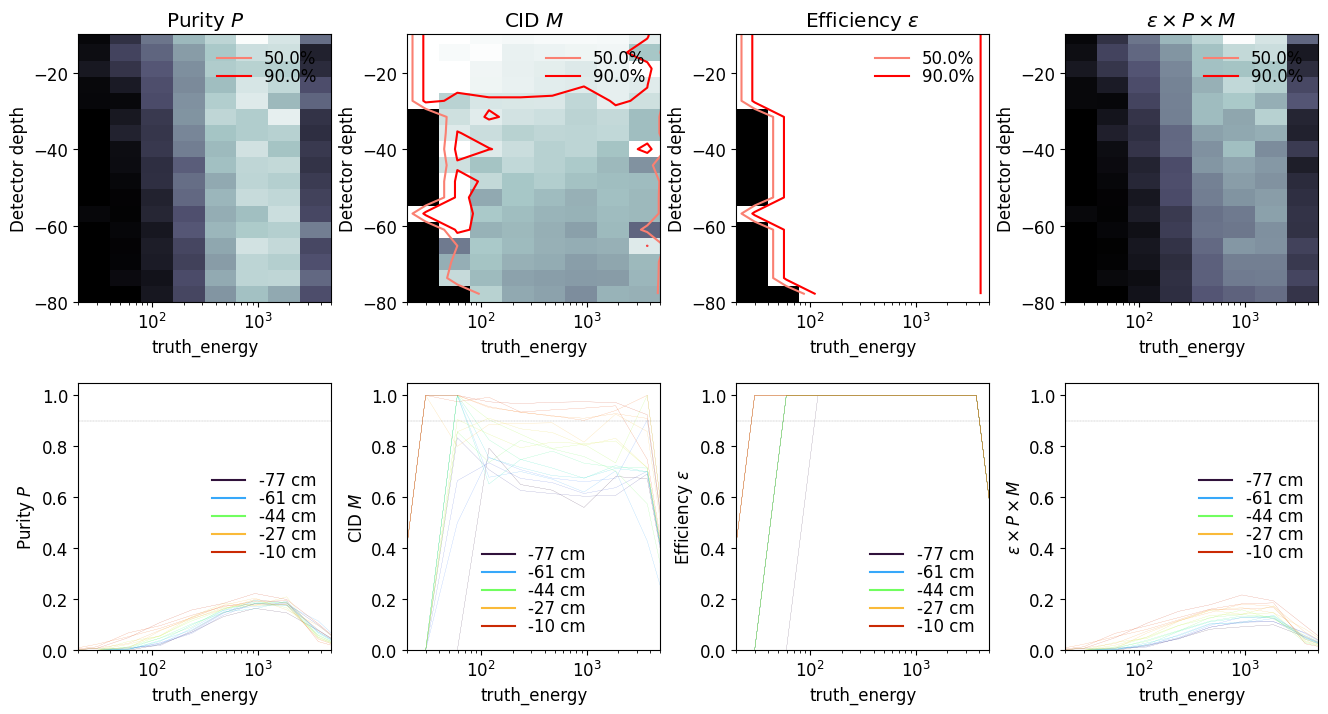

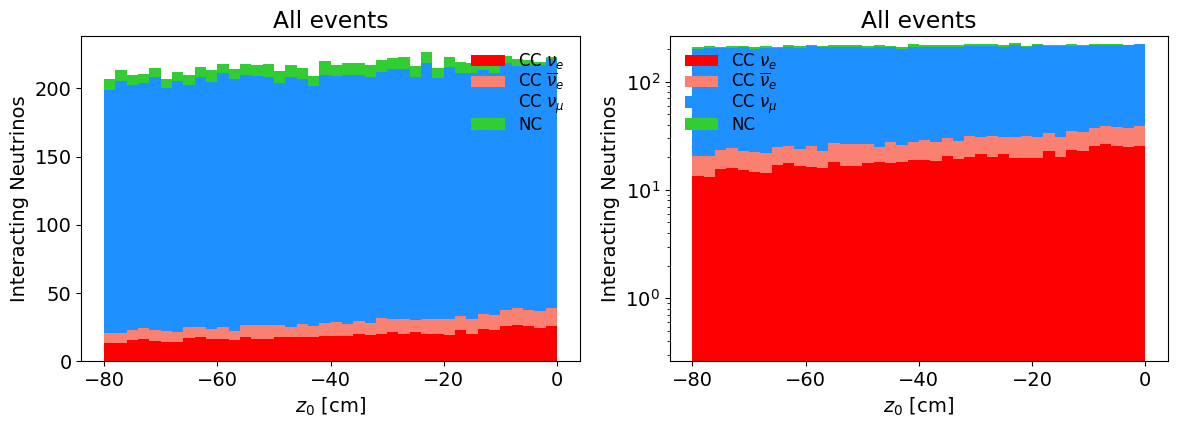

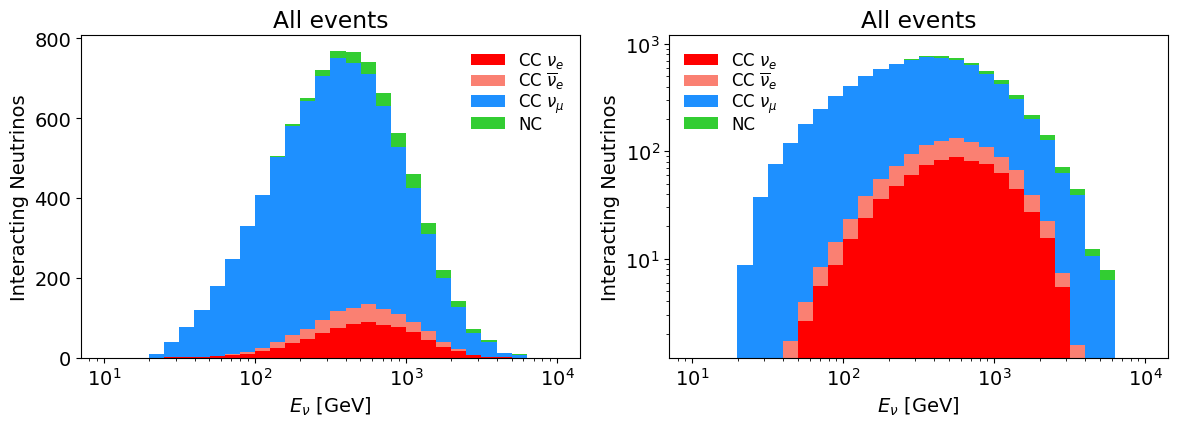

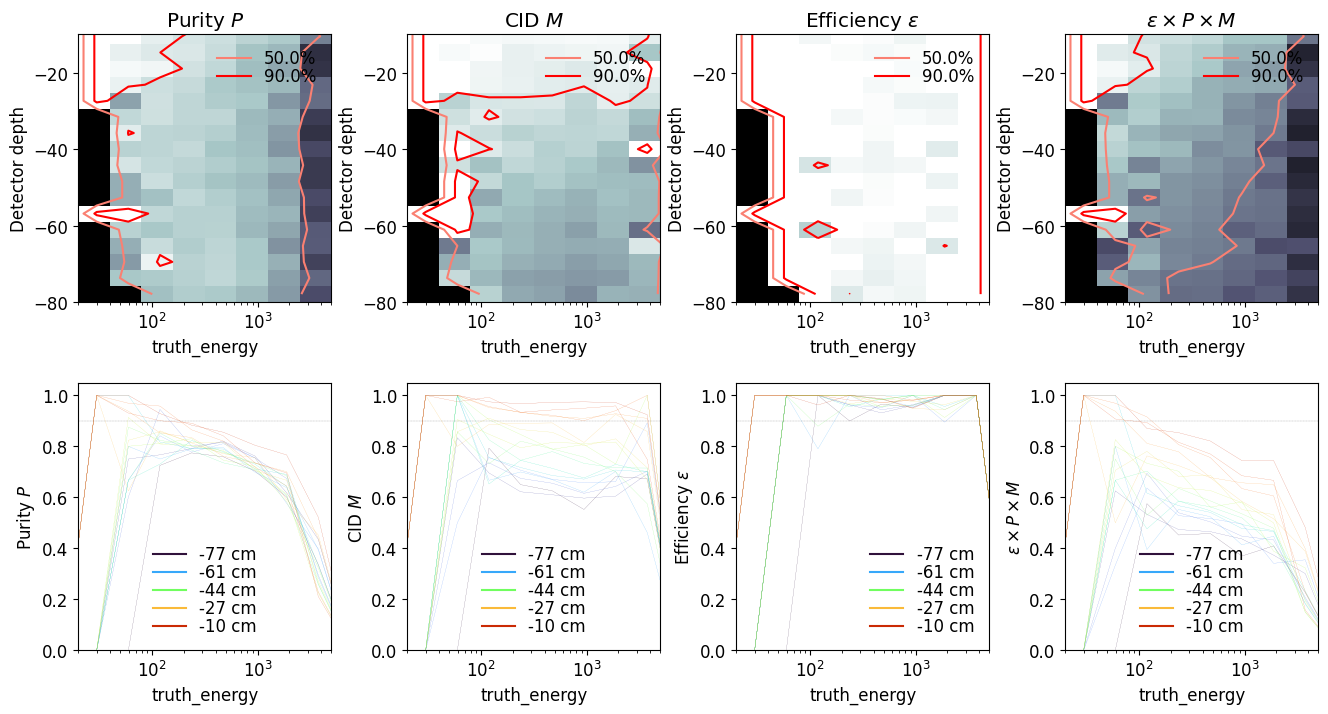

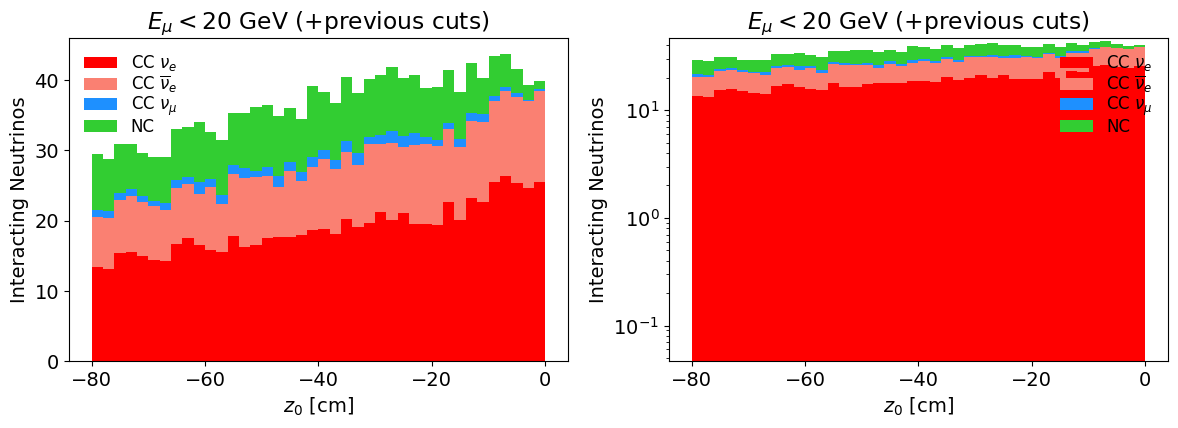

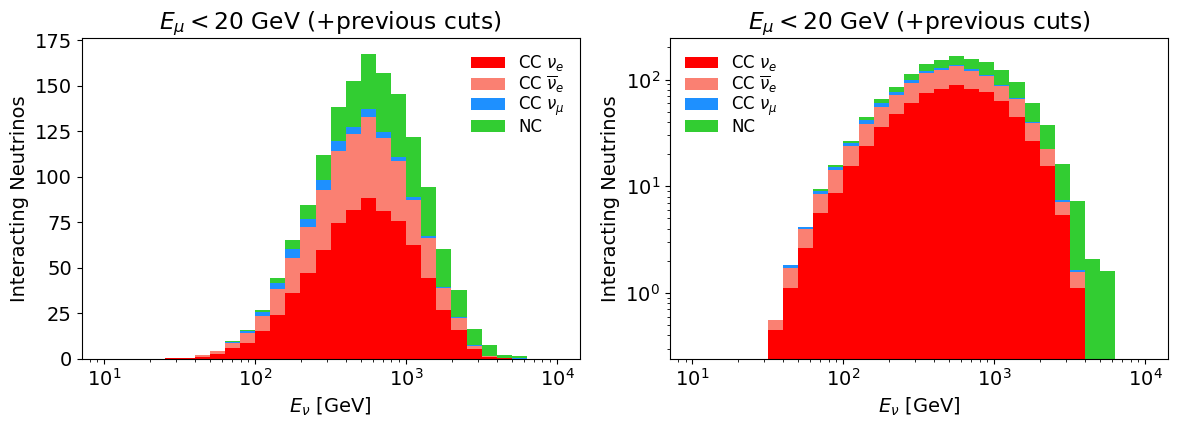

Rm 0.9937383181580157 of numu


In [18]:
eobs='truth_energy'  #'e_e'
elabel = r'$E_\nu$ [GeV]'

yspread=1e3
cutmsg0 = [r'No cuts',r'$E_\mu$ cut']  #Titles for the first cut, compared agains atll eventes w/o/ any cuts
cutmsg = [r' (cut alone)',r' (+previous cuts)']  #At each following step, illustrate the cut's effect alone + together with others

e_mu_cut = 20.  #Cut events containing muons w/ higher energy than this [GeV] 

#Init to all events
dftmp =  df
dftot = df

for i,dfn in enumerate([df,df[df['e_mu']<e_mu_cut]]):
    dftmp=dfn
    efficiency(data=dftmp,uncut=df)
    titlestr = r'All events' if i==0 else r'$E_\mu<$'+str(int(e_mu_cut))+r' GeV'+cutmsg[i]
    get_stacked_histogram(
        data=dftmp,
        observable='z0',
        bins=z0bins_default,
        xlabel=r'$z_0$ [cm]',
        title=titlestr,
        xlog=False,
        yspread=yspread,
    )
    get_stacked_histogram(
        data=dftmp,
        observable=eobs,
        bins=ebins_default,
        xlabel=elabel,
        title=titlestr,
        xlog=True,
        yspread=yspread,
    )
print('Rm',1.-sum(list(dftmp[dftmp['set'].isin(['numu'])]['weight']))/sum(list(dftot[dftot['set'].isin(['numu'])]['weight'])),'of numu')
dftot=dftmp  #For storing the cumulative effect of all cuts in later steps

EM energy ratio of total visible energy. 50% removes ~all high-E NC and some signal events. Use at least 30%.

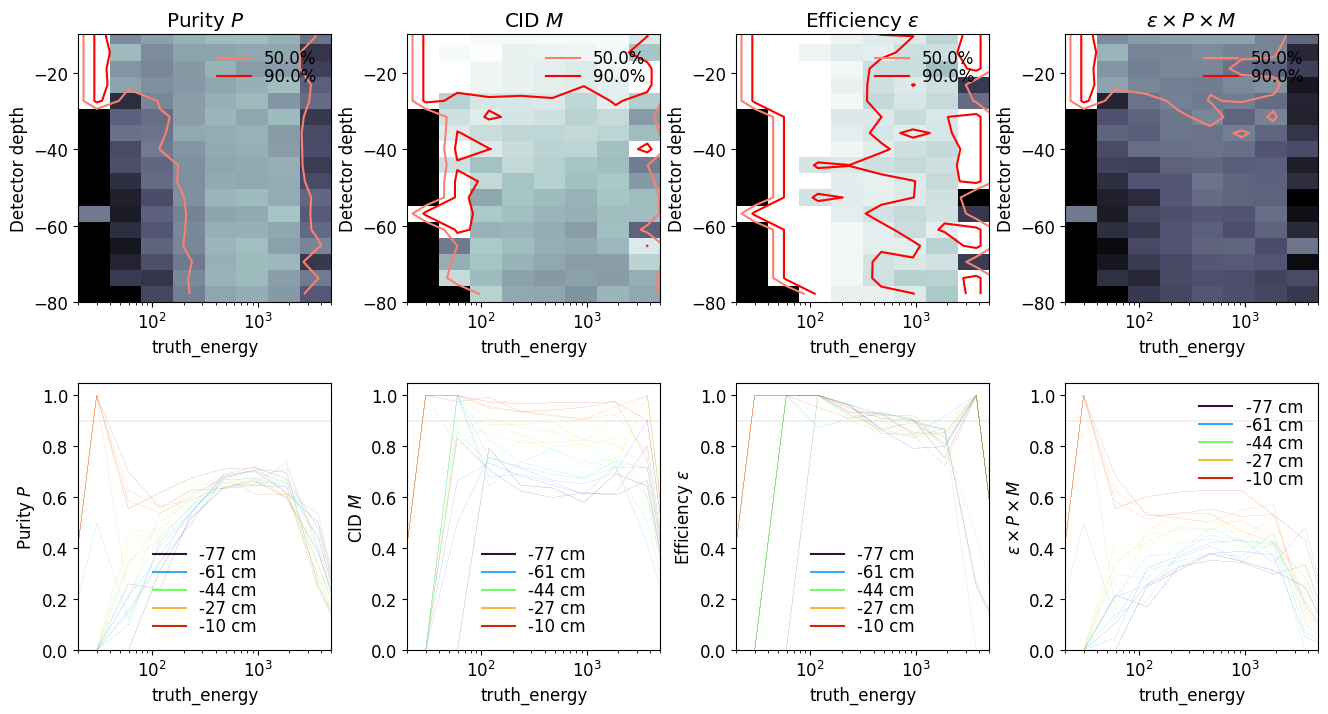

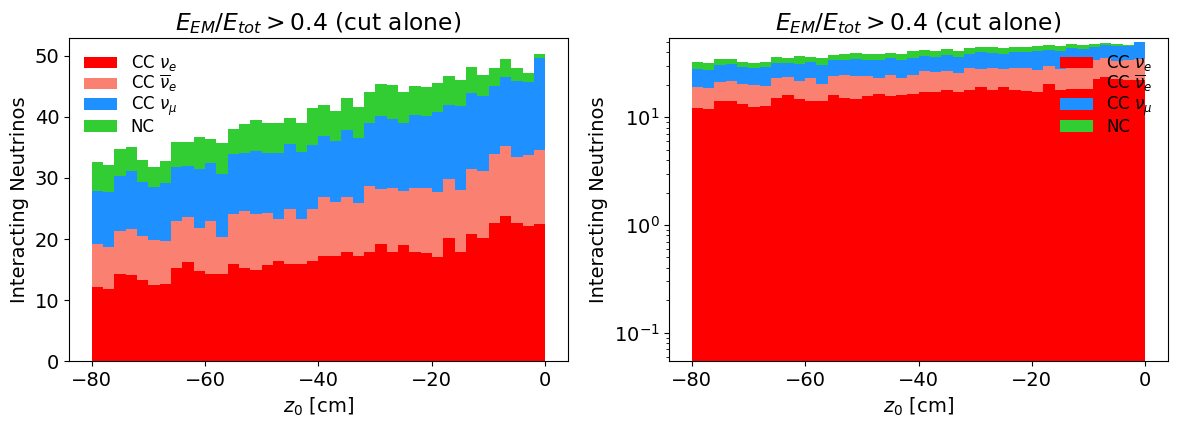

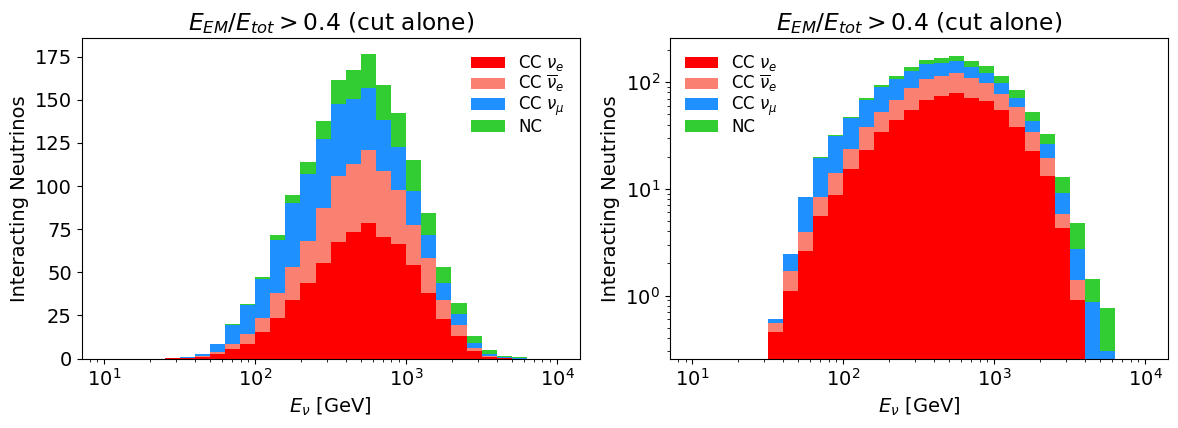

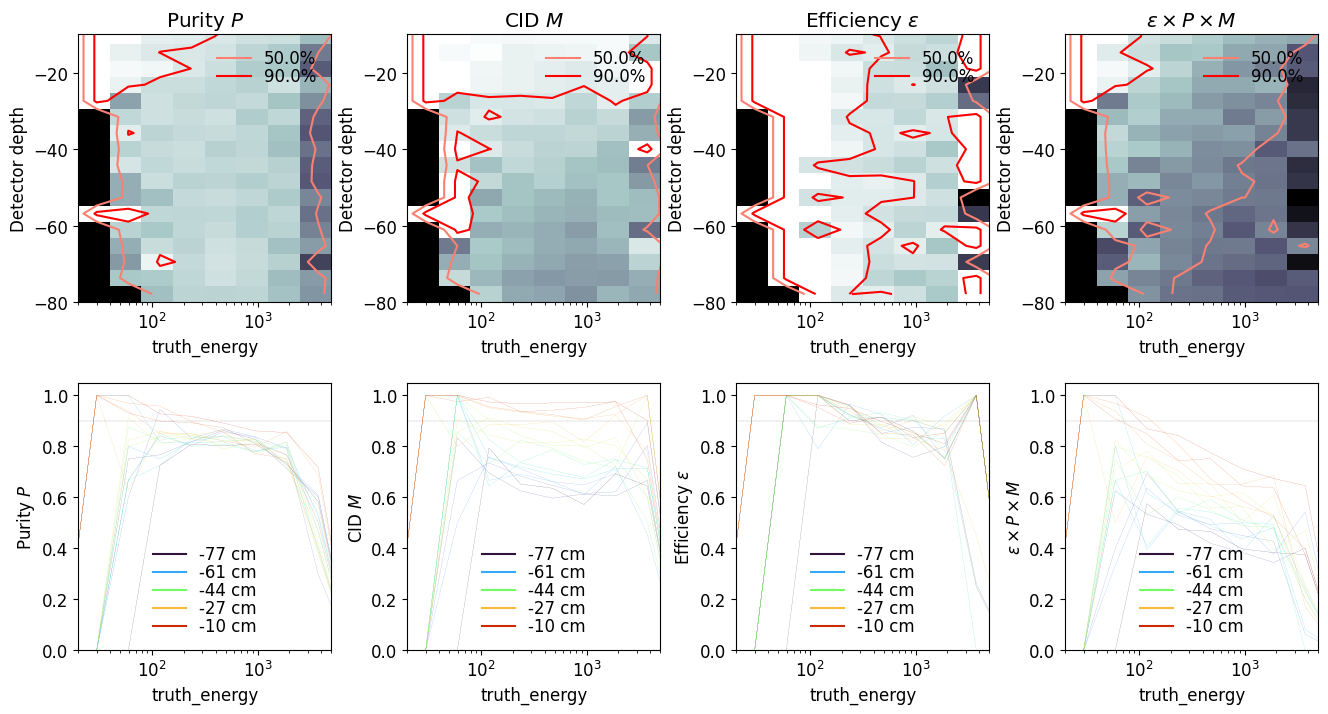

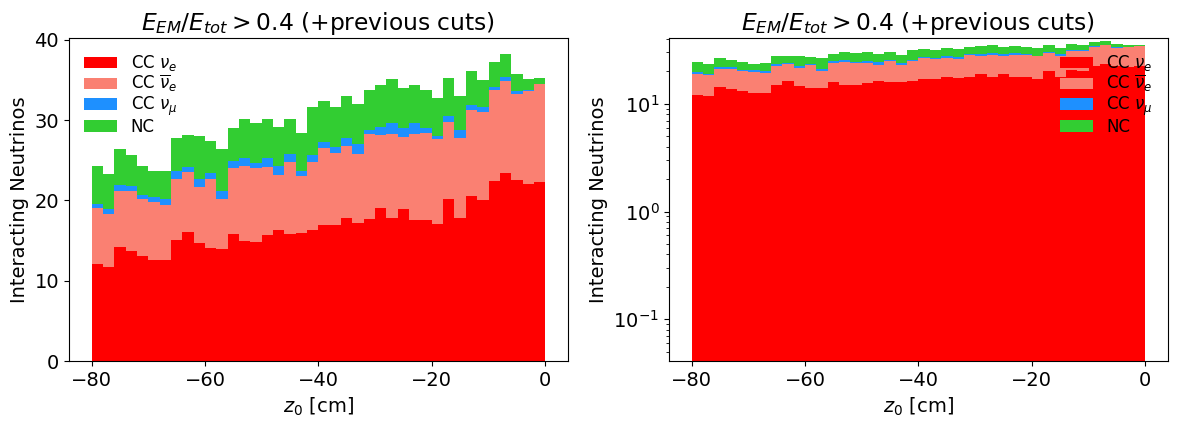

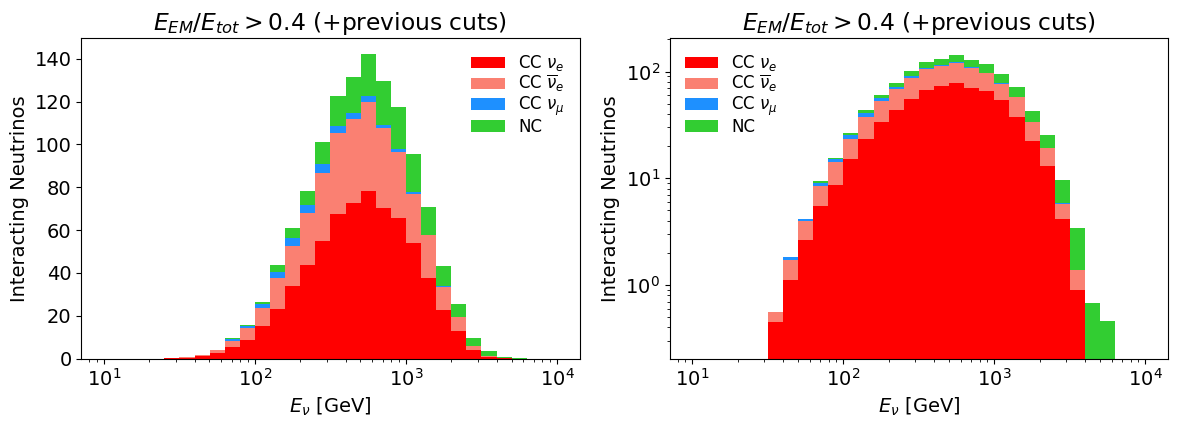

Rm 0.40361871721651466 of NC


In [19]:
e_em_e_tot_cut = 0.4
for i,dfn in enumerate([df,dftot]):
    dftmp = dfn[dfn['e_em']/dfn['e_tot']>e_em_e_tot_cut]
    efficiency(data=dftmp,uncut=df)
    titlestr = r"$E_{EM}/E_{tot}>"+str(e_em_e_tot_cut)+"$"+cutmsg[i]
    get_stacked_histogram(
        data=dftmp,
        observable='z0',
        bins=np.linspace(z0min,0,41),
        xlabel=r'$z_0$ [cm]',
        title=titlestr,
        xlog=False,
        yspread=yspread,
    )
    get_stacked_histogram(
        data=dftmp,
        observable=eobs,
        bins=ebins_default,
        xlabel=elabel,
        title=titlestr,
        xlog=True,
        yspread=yspread,
    )
print('Rm',1.-sum(list(dftmp[dftmp['set'].isin(['NC'])]['weight']))/sum(list(dftot[dftot['set'].isin(['NC'])]['weight'])),'of NC')
dftot=dftmp  #Update dftot

A significant enough portion of the EM energy must be due to the highest-energy electron in the event. 
Similar effects to the $E_{\rm EM}/E_{tot}$ cut, but slightly more damaging to signal. However, doesn't really hurt a 20 cm detector.

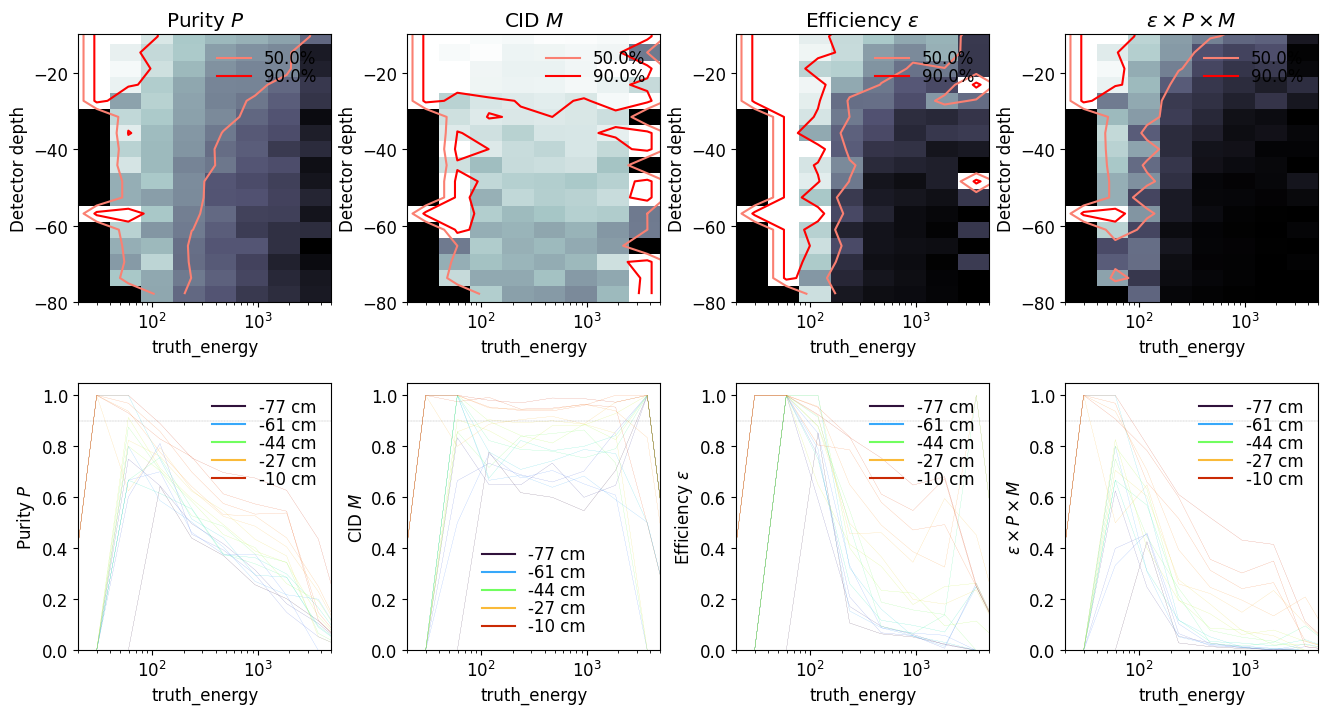

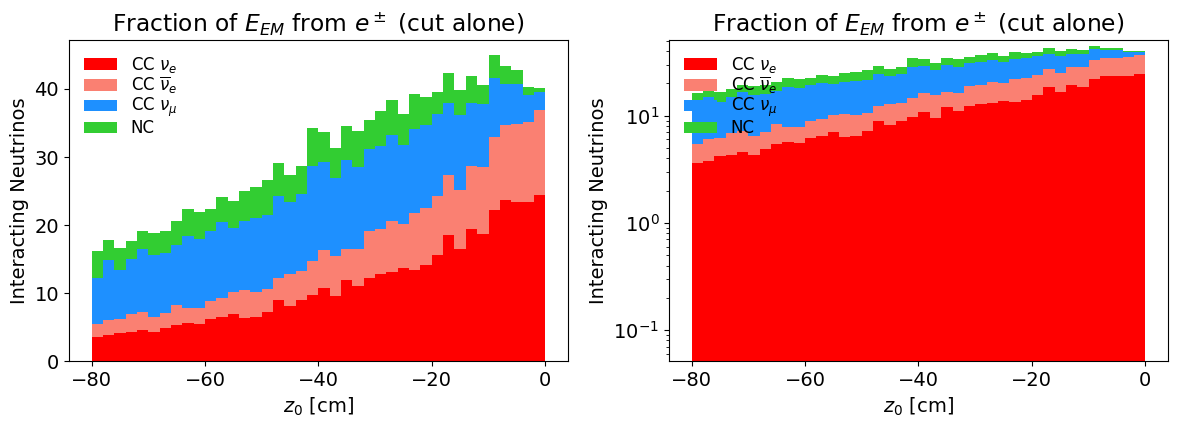

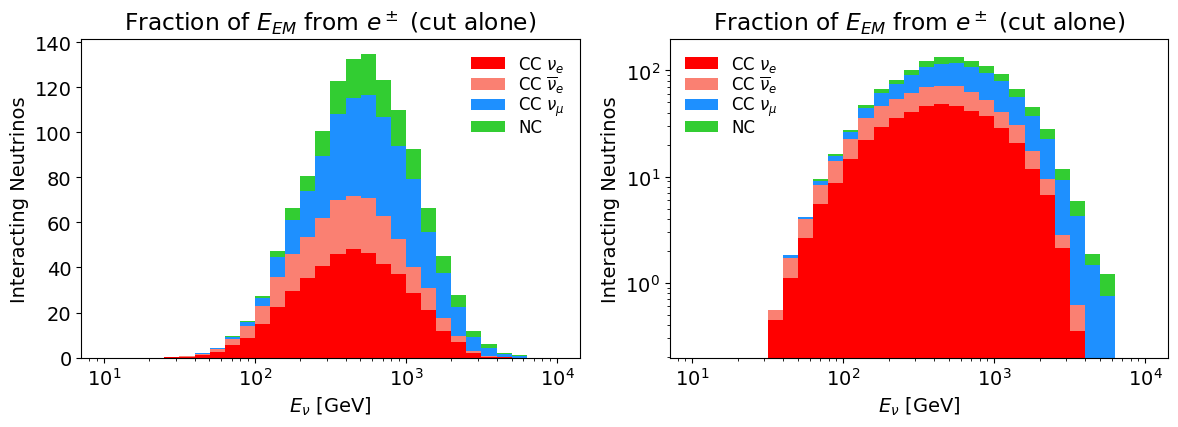

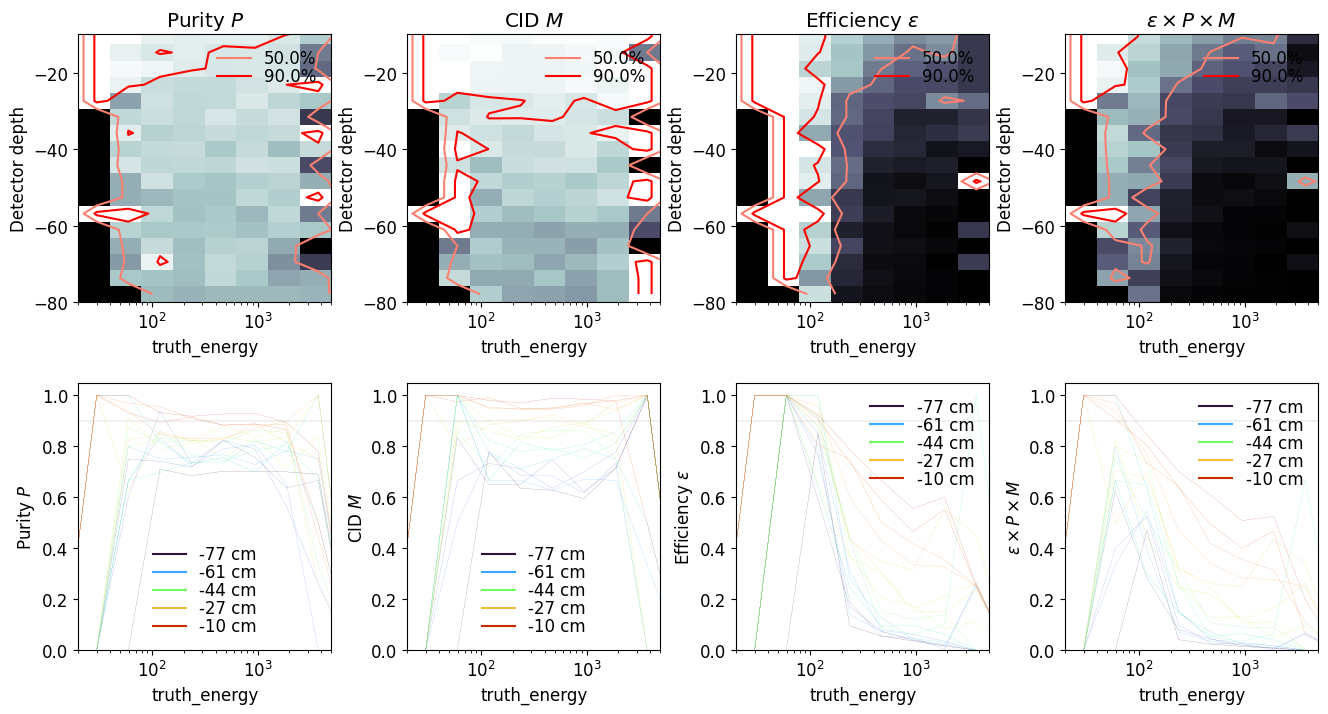

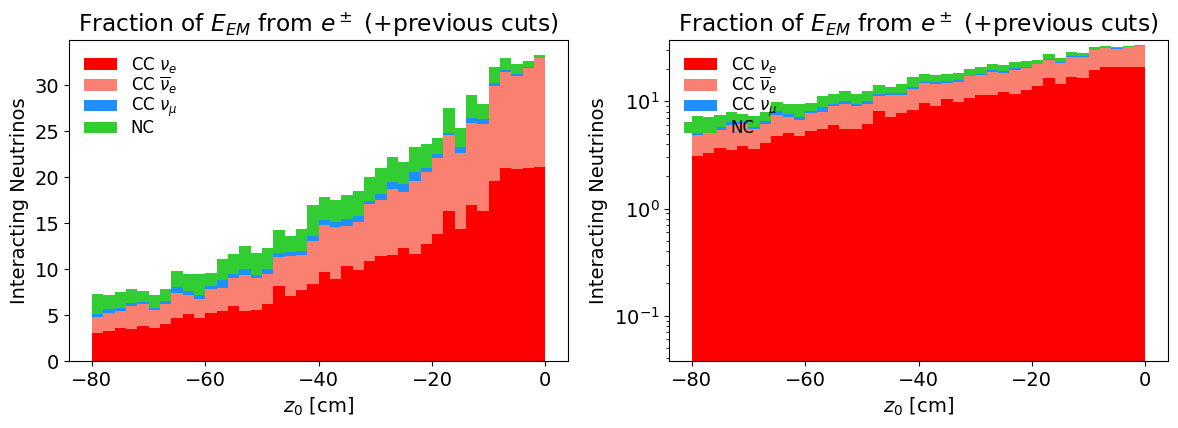

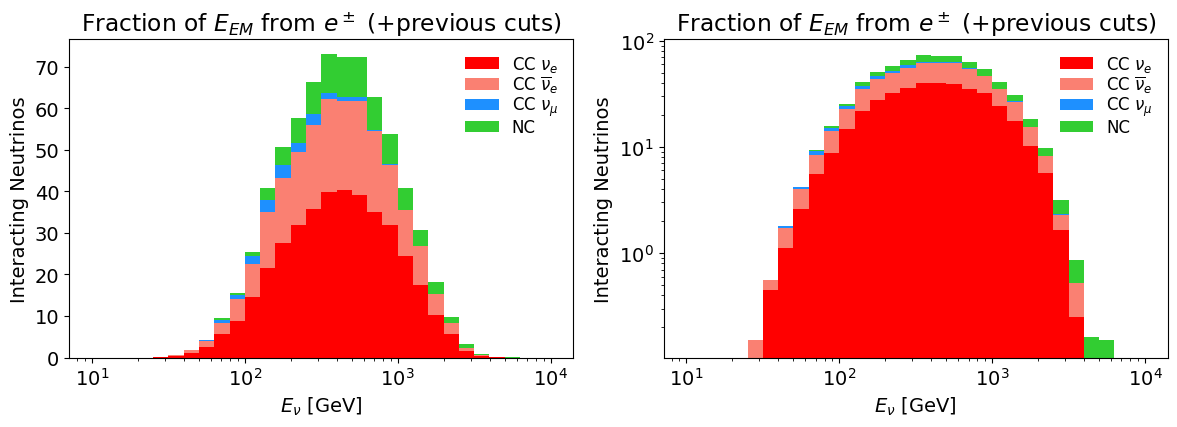

Rm 0.520287198259221 of NC


In [20]:
for i,dfn in enumerate([df,dftot]):
    dftmp = dfn[dfn['e_e']/dfn['e_em']>0.25]  
    efficiency(data=dftmp,uncut=df)
    titlestr = r"Fraction of $E_{EM}$ from $e^\pm$"+cutmsg[i]
    get_stacked_histogram(
        data=dftmp,
        observable='z0',
        bins=np.linspace(z0min,0,41),
        xlabel=r'$z_0$ [cm]',
        title=titlestr,
        xlog=False,
        yspread=yspread,
    )
    get_stacked_histogram(
        data=dftmp,
        observable=eobs,
        bins=ebins_default,
        xlabel=elabel,
        title=titlestr,
        xlog=True,
        yspread=yspread,
    )
print('Rm',1.-sum(list(dftmp[dftmp['set'].isin(['NC'])]['weight']))/sum(list(dftot[dftot['set'].isin(['NC'])]['weight'])),'of NC')
dftot=dftmp  #Update dftot

Restrict to events with high-energy electrons. Kills low-$E$ signal events, affects also the peak around $E_\nu$=500 GeV.

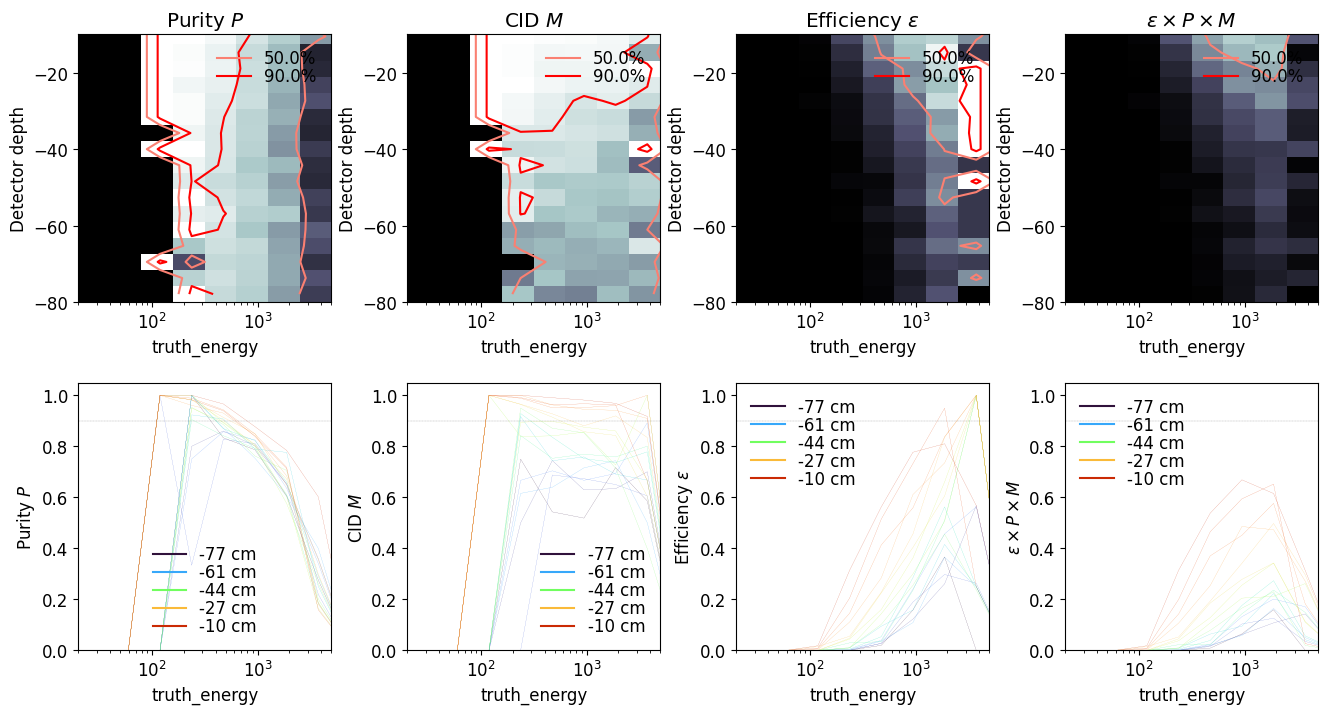

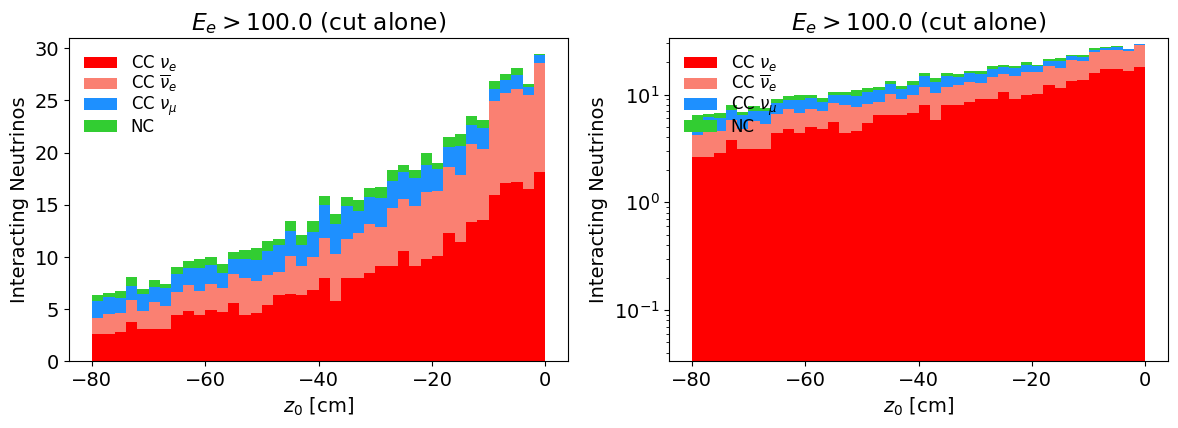

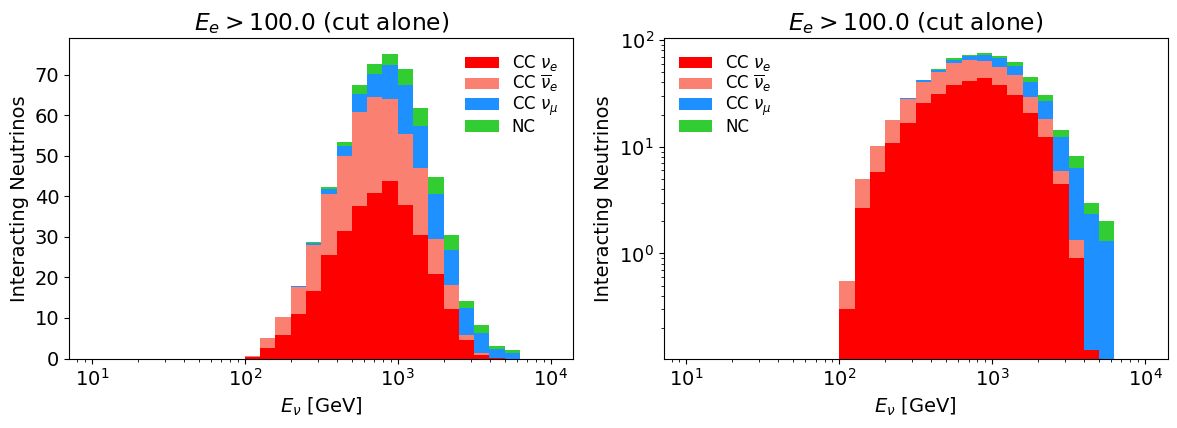

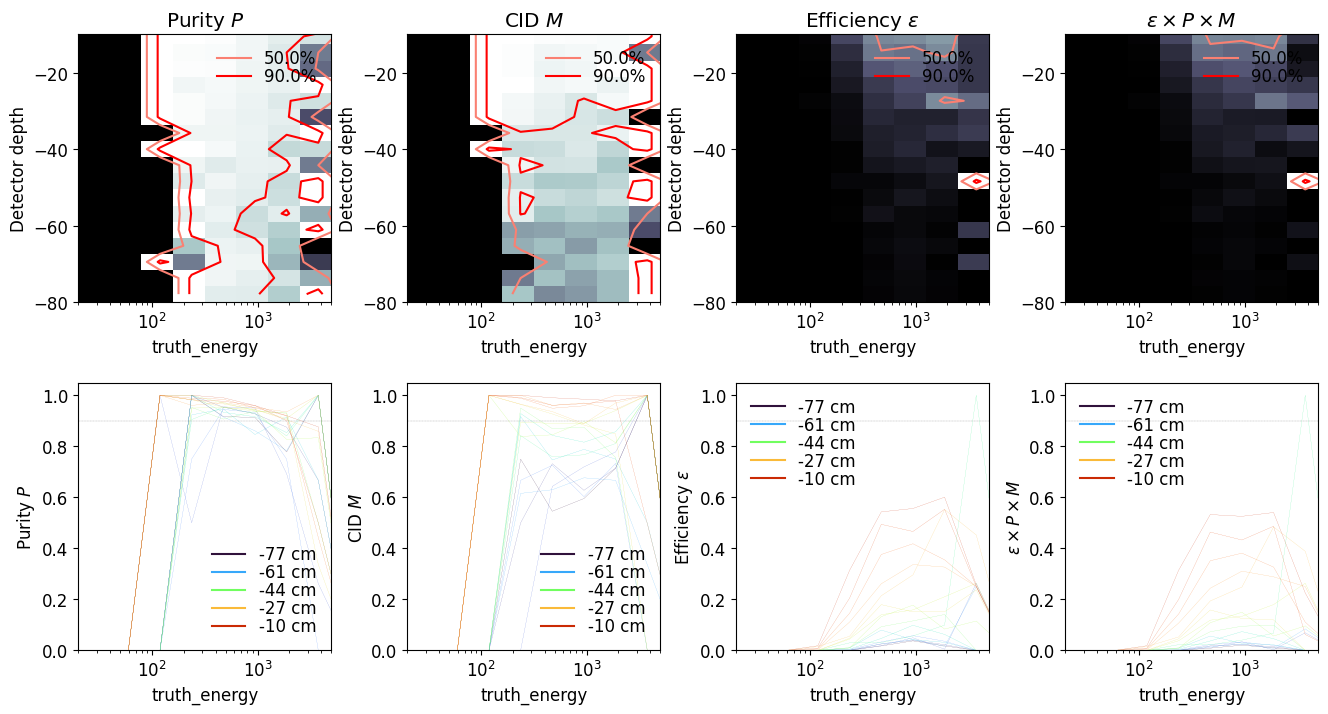

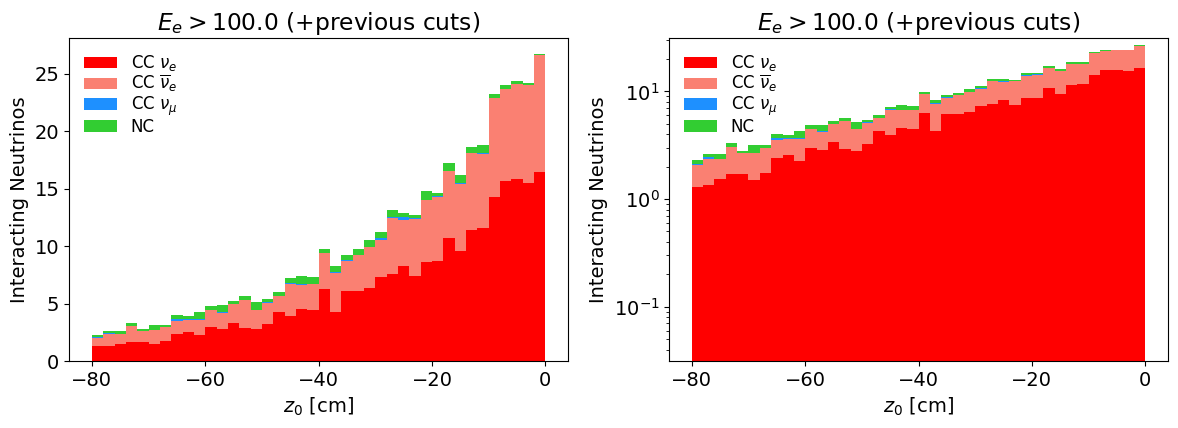

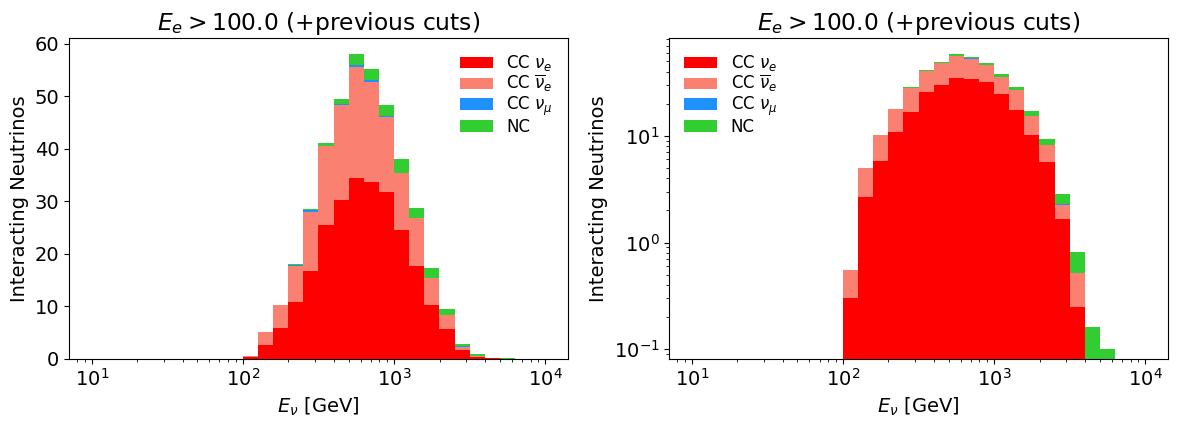

Rm 0.8146355348657752 of remaining bg


In [21]:
e_e_cut = 100.
for i,dfn in enumerate([df,dftot]):
    dftmp = dfn[dfn['e_e']>e_e_cut]
    efficiency(data=dftmp,uncut=df)
    titlestr = r"$E_e>"+str(e_e_cut)+"$"+cutmsg[i]
    get_stacked_histogram(
        data=dftmp,
        observable='z0',
        bins=np.linspace(z0min,0,41),
        xlabel=r'$z_0$ [cm]',
        title=titlestr,
        xlog=False,
        yspread=yspread,
    )
    get_stacked_histogram(
        data=dftmp,
        observable=eobs,
        bins=ebins_default,
        xlabel=elabel,
        title=titlestr,
        xlog=True,
        yspread=yspread,
    )
print('Rm',1.-sum(list(dftmp[dftmp['set'].isin(['NC','numu'])]['weight']))/sum(list(dftot[dftot['set'].isin(['NC','numu'])]['weight'])),'of remaining bg')
dftot=dftmp  #Update dftot

Finally, restrict vertex position to correspond to the realistic detector. 
Setting this to >20 cm actually removes some low-E NC events, too.
This of course limits also CC nue statistics, but their number decreases linearly accross all e_lep.

This is compared to the corresponding highest energy electron energy distribution for $\nu_e$CC only, to estimate signal losses from cuts.

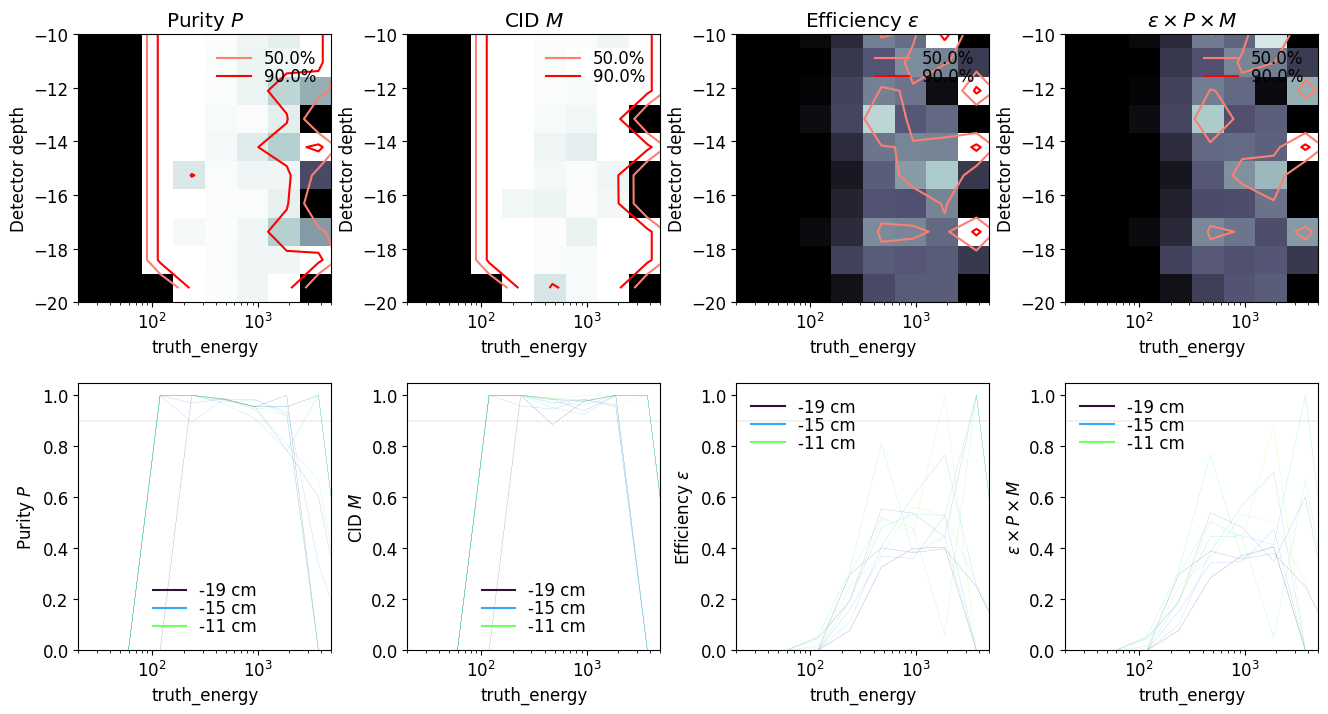

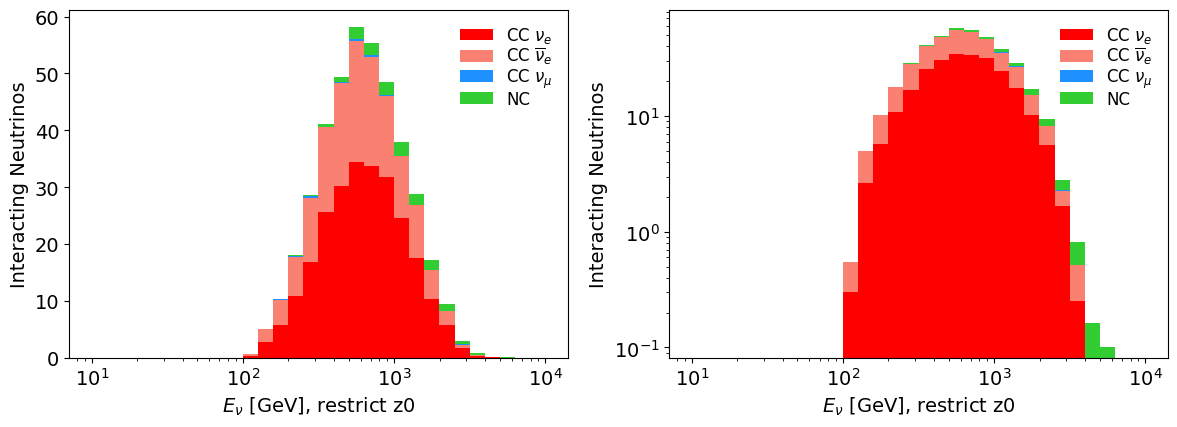

Rm 0.0 of remaining bg


In [22]:
z0cutFASER = -20.  #At FASER, the detector will be 20 cm long. Longer detectors may be considered at FASER2.
df_CNC=dftot  #Save the result of the cut-and-count analysis before restricting to a smaller z0 for FASER
df_FASER = df[df['z0']>z0cutFASER]  #Restrict otherwise uncut data to FASER length
df_CNC_FASER = df_CNC[df_CNC['z0']>z0cutFASER]  #Restrict otherwise uncut data to FASER length
#Not so interesting to plot the effect of z0 restriction alone like the previous cuts. Just plot all cuts.
#Considering efficiency is only meaningful for same-size detectors
eff_CNC_FASER = efficiency(data=df_CNC_FASER,uncut=df_FASER,z0bins=np.linspace(z0cutFASER,0,20))
get_stacked_histogram(
    data=dftmp, 
    observable=eobs, 
    bins=np.logspace(1,4,31), 
    xlabel=elabel+r', restrict z0', 
    xlog=True, 
    yspread=1e3,
)
print('Rm',1.-sum(list(dftmp[dftmp['set'].isin(['NC','numu'])]['weight']))/sum(list(dftot[dftot['set'].isin(['NC','numu'])]['weight'])),'of remaining bg')
dftot=dftmp  #Update dftot

The statement we can make above is that in a cut and count analysis, we can reach well over 90% sample purity and near-perfect charge identification in a 20 cm detector, retaining >50% of the signal events with $E_\nu>200$ GeV.

Print some event count summaries after the various cuts (assuming a 20 cm detector since the beginning this time around).

In [23]:
#Restrict to FASER-PS size
dfcut1 = df[df['z0']>-20.]

#Scaling to make the event numbers correspond to FPF lumi used in paper.
#These factors are both approx 1.4 but get the separately because we can.
FPFscaling = {'nue':   1120./sum(list(dfcut1[dfcut1['set'].isin(['nue'   ])]['weight'])),\
              'nuebar': 525./sum(list(dfcut1[dfcut1['set'].isin(['nuebar'])]['weight']))}
for tag in ['numu','NC']: FPFscaling[tag] = (FPFscaling['nue']+FPFscaling['nuebar'])*0.5  #For others, assume avg. factor

#Other cuts
dfcut2 = dfcut1[dfcut1['e_mu']<20.]
dfcut3 = dfcut2[dfcut2['e_em']/dfcut2['e_tot']>0.4 ]  #50% removes ~all high-E NC and some signal events. Use at least 30%
dfcut4 = dfcut3[dfcut3['e_e' ]/dfcut3['e_em' ]>0.25]  #Like e_em/e_tot, but more damaging to signal. OK when z0>-20cm
dfcut5 = dfcut4[dfcut4['e_e']>100.]  #Kills low-E signal events, affects even the peak around Enu=500 GeV
for i,dfn in enumerate([df,dfcut1,dfcut2,dfcut3,dfcut4,dfcut5]):
    print('After',i,'cuts: nue',   int(FPFscaling['nue'   ]*sum(list(dfn[dfn['set'].isin(['nue'   ])]['weight']))),\
                        ', nuebar',int(FPFscaling['nuebar']*sum(list(dfn[dfn['set'].isin(['nuebar'])]['weight']))),\
                        ', numu',  int(FPFscaling['numu'  ]*sum(list(dfn[dfn['set'].isin(['numu'  ])]['weight']))),\
                        ', NC',    int(FPFscaling['NC'    ]*sum(list(dfn[dfn['set'].isin(['NC'    ])]['weight']))))

After 0 cuts: nue 3607 , nuebar 1722 , numu 33397 , NC 1347
After 1 cuts: nue 1120 , nuebar 525 , numu 8298 , NC 243
After 2 cuts: nue 1111 , nuebar 520 , numu 34 , NC 235
After 3 cuts: nue 984 , nuebar 490 , numu 22 , NC 144
After 4 cuts: nue 856 , nuebar 434 , numu 15 , NC 73
After 5 cuts: nue 612 , nuebar 332 , numu 1 , NC 19


### ML training

Train a Boosted Decision Tree (BDT) to classify whether the events are $\nu_e$CC, $\nu_\mu$CC or NC.
The `data` to be considered here is therefore the set label (nue,numu,NC), and the observables are the features based on which the ML algorithm is to make it's decision.

In [24]:
#AUX function to turn a string label "y", indicating the dataset the event belongs to, into an integer.
#Returns 1 for non-nue/nuebar events, 0 for others
def tagAsInt(y):
    if   y=='nue':    return 0
    elif y=='nuebar': return 1
    elif y=='numu':   return 2
    else:             return 3  #NC
#Inverts the above
def tagAsStr(y):
    if    y==0: return 'nue'  
    elif  y==1: return 'nuebar'
    elif  y==2: return 'numu'
    else:       return 'NC'  #3

def BDTanalysis(data,plotROC=True):

    #Input features: N.B. truth_energy and set removed before training.
    #The keys are included here so that the info can be added to the result later on for checking
    features = ['truth_energy','e_em','e_ch','e_tot','z0','e_e','e_mu','lep_pid','chEM','lep_theta','em_theta_std','em_theta_max']
    
    X, yset, weights = data[features], data['set'], data['weight']

    #Define preprocessing: log-transform and scaling
    test_size=0.75
    X_train, X_test, yset_train, yset_test, weights_train, weights_test = train_test_split(
        X, yset, weights, test_size=test_size, random_state=137
    )
    
    X_train.reset_index(      drop=True, inplace=True)
    X_test.reset_index(       drop=True, inplace=True)
    yset_train.reset_index(   drop=True, inplace=True)
    yset_test.reset_index(    drop=True, inplace=True)
    weights_train.reset_index(drop=True, inplace=True)
    weights_test.reset_index( drop=True, inplace=True)
    
    #Now turn event labels into integers, indicating if true nueCC or nuebarCC events were found, or b.g.
    y_train = pd.Series([tagAsInt(y=y) for y in yset_train])
    y_test  = pd.Series([tagAsInt(y=y) for y in yset_test ])
    
    #Skip truth energy and vpid from the features before training, not observable
    T_test = X_test[['truth_energy']]
    X_train = X_train[features[1:]]
    X_test = X_test[features[1:]]

    #Create a pipeline with preprocessing and the classifier
    pipeline = Pipeline([
        ('scale', QuantileTransformer()) ,   
        ('bdt', GradientBoostingClassifier(
            n_estimators=200,
            learning_rate=0.03,
            max_depth=3,
            #random_state=137,
            min_samples_split=5,
            min_samples_leaf=5,
            max_features='sqrt',
            subsample=0.8,
        ))
    ])
    
    # train BDT
    _=pipeline.fit(X_train, yset_train, bdt__sample_weight=weights_train)

    # Make predictions
    y_pred = pipeline.predict(X_test)
    y_pred_prob = pipeline.predict_proba(X_test)
    Nyprob = len(y_pred_prob[0])
    y_pred_probs = [y_pred_prob[:, i] for i in range(Nyprob)]
    #y_pred_prob_train = pipeline.predict_proba(X_train)
    #y_pred_probs_train = [y_pred_prob_train[:, i] for i in range(Nyprob)]
    
    #Turn nue, numu, NC labels into 1s and 0s, required for accuracy score / comparison
    y_pred = pd.Series([tagAsInt(y=y) for y in y_pred])
    
    # Evaluate the model
    accuracy = accuracy_score(y_test, y_pred, sample_weight=weights_test)
    
    #Store the results to `yprob`
    processed = X_test.copy()
    processed['truth_energy'] = T_test['truth_energy']
    processed['set'] = yset_test                           #Truth set as a string
    processed['y'] = np.array(y_test)                      #Truth set as an integer
    processed['ypred'] = y_pred
    processed['pred_set'] = [tagAsStr(y) for y in y_pred]  #Predicted set
    for i in range(Nyprob): processed['yprob'+str(i)] = y_pred_probs[i]
    processed['weight'] = weights_test / test_size

    return processed

### Results of ML analysis

In [25]:
def printBDTevents(bdt):
    print('All events',sum(list(bdt['weight'])))
    bdt_nue_truth    = bdt[bdt['set'].isin(['nue'   ])]
    bdt_nuebar_truth = bdt[bdt['set'].isin(['nuebar'])]
    print('nue, nuebar events (truth)',sum(list(bdt_nue_truth['weight'])),sum(list(bdt_nuebar_truth['weight'])))
    bdt_nue_pred    = bdt[bdt['pred_set'].isin(['nue'   ])]
    bdt_nuebar_pred = bdt[bdt['pred_set'].isin(['nuebar'])]
    print('nue, nuebar events (pred)',sum(list(bdt_nue_pred['weight'])),sum(list(bdt_nuebar_pred['weight'])))

def BDTresults(data2bdt,uncutdata):
    bdt = BDTanalysis(data=data2bdt,plotROC=False)
    
    #Plot BDT results
    for iyprob in range(4):
        print('BDT results including all events')
        get_stacked_histogram(
            data=bdt, 
            observable="yprob"+str(iyprob), 
            bins=np.linspace(0,1,25+1), 
            xlabel="yprob"+str(iyprob), 
            xlog=False,
            yspread=1e3,
        )
        print('BDT results for events classified as signal')
        get_stacked_histogram(
            data=bdt[bdt['pred_set'].isin(['nue','nuebar'])], 
            observable="yprob"+str(iyprob), 
            bins=np.linspace(0,1,25+1), 
            xlabel="yprob"+str(iyprob), 
            xlog=False,
            yspread=1e3,
        )
    
    #Plot z and E distributions
    global z0min
    get_stacked_histogram(
        data=bdt[bdt['pred_set'].isin(['nue','nuebar'])],
        observable='z0',
        bins=z0bins_default,
        xlabel=r'$z_0$ [cm]',
        xlog=False,
        yspread=1e3,
    )
    get_stacked_histogram(
        data=bdt[bdt['pred_set'].isin(['nue','nuebar'])],
        observable='truth_energy', #'e_e',
        bins=ebins_default,
        xlabel=r'$E_\nu$ [GeV]',
        xlog=True,
        yspread=1e3,
    )
    
    #Print relevant event statistics
    printBDTevents(bdt)
    
    #Find and plot efficiency
    effdict = efficiency(data=bdt,uncut=uncutdata)
    
    return bdt,effdict

Train the BDT, imposing the cut on muon energies, which does minimal damage to the signal, but can help the BDT out.
We see that there are numu and NC events across all yprob values, but particularly at very low values. Let's also print the numbers of all events, how many of them are true signal events, and how many did the BDT classify as such.

BDT results including all events


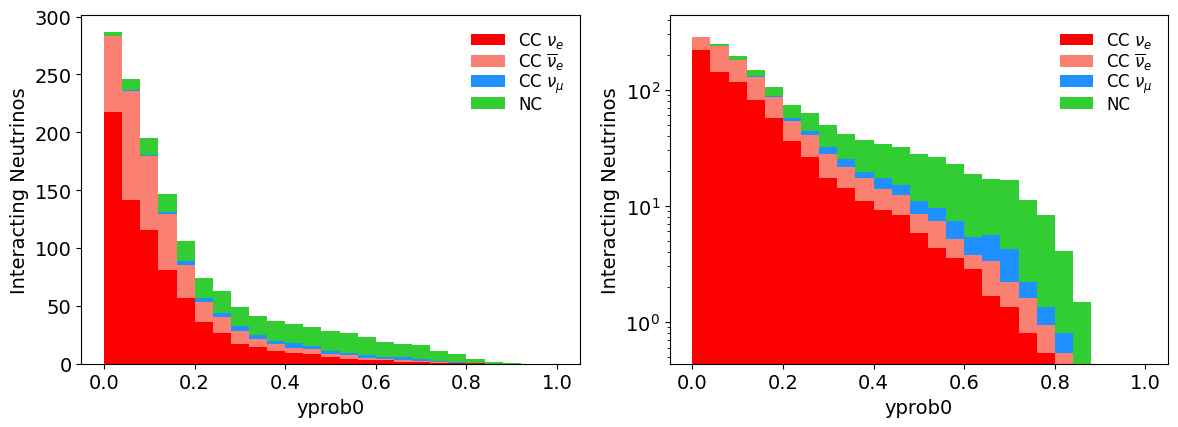

BDT results for events classified as signal


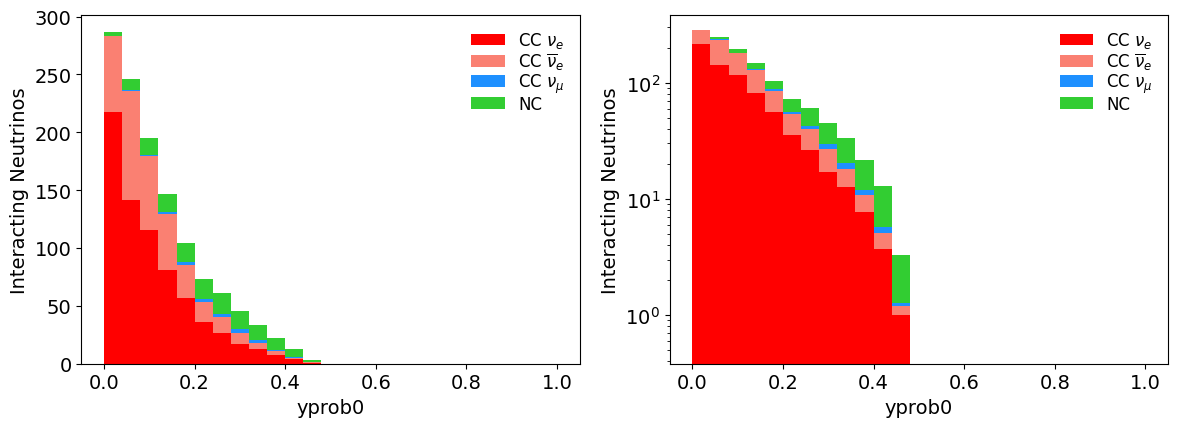

BDT results including all events


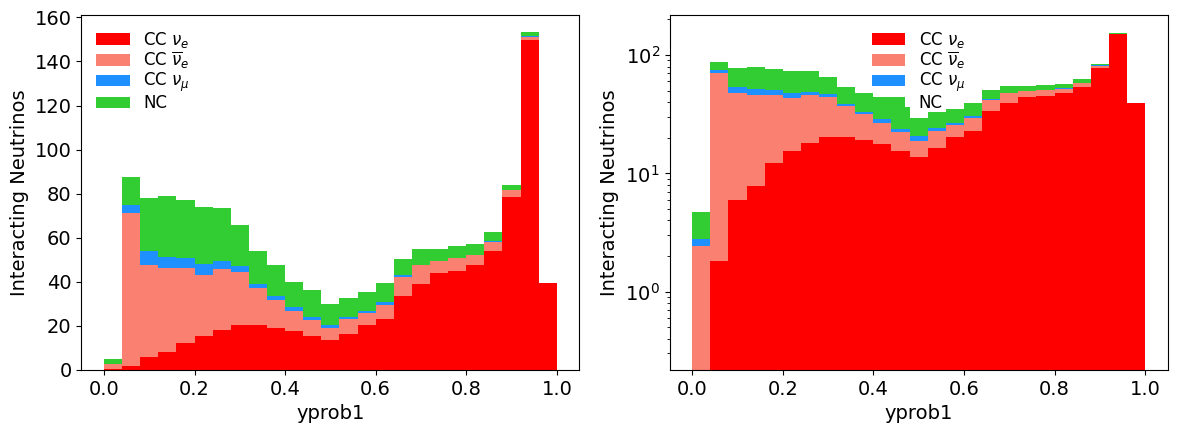

BDT results for events classified as signal


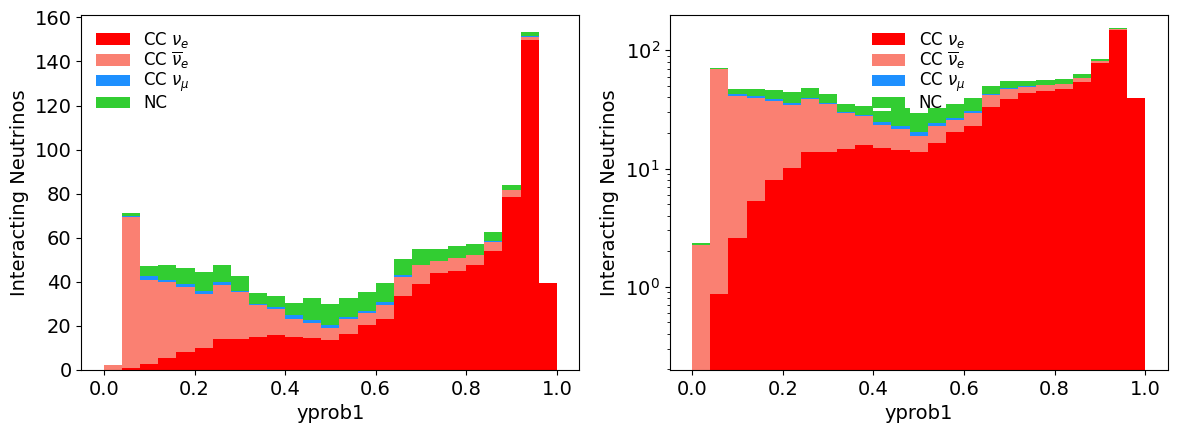

BDT results including all events


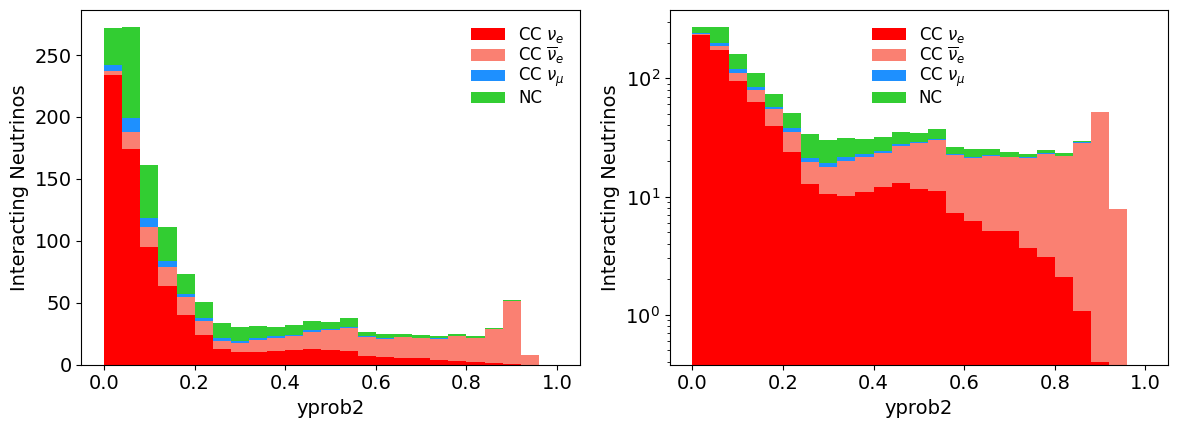

BDT results for events classified as signal


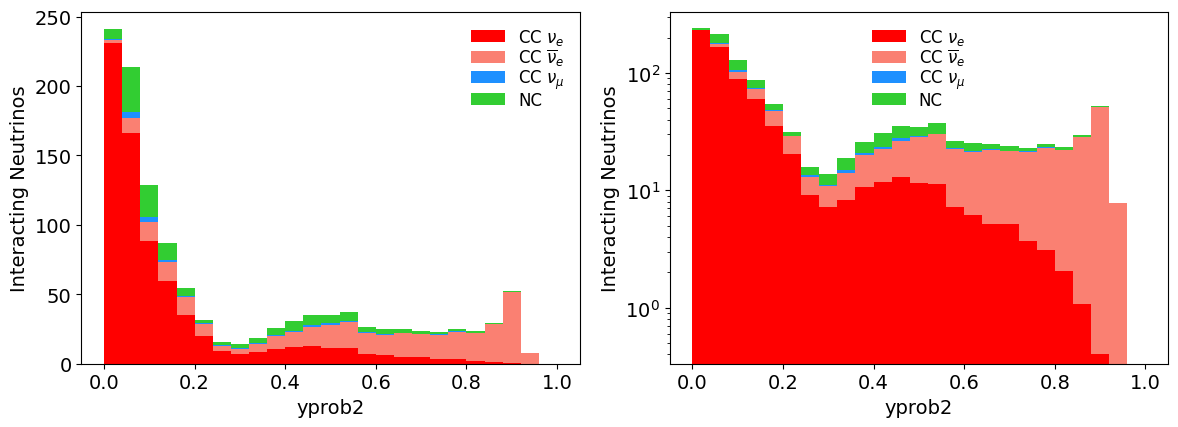

BDT results including all events


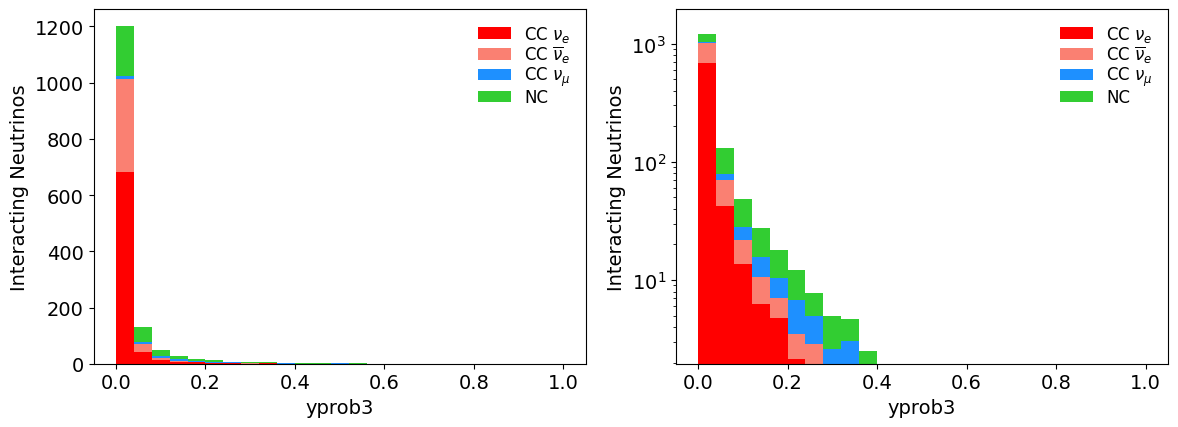

BDT results for events classified as signal


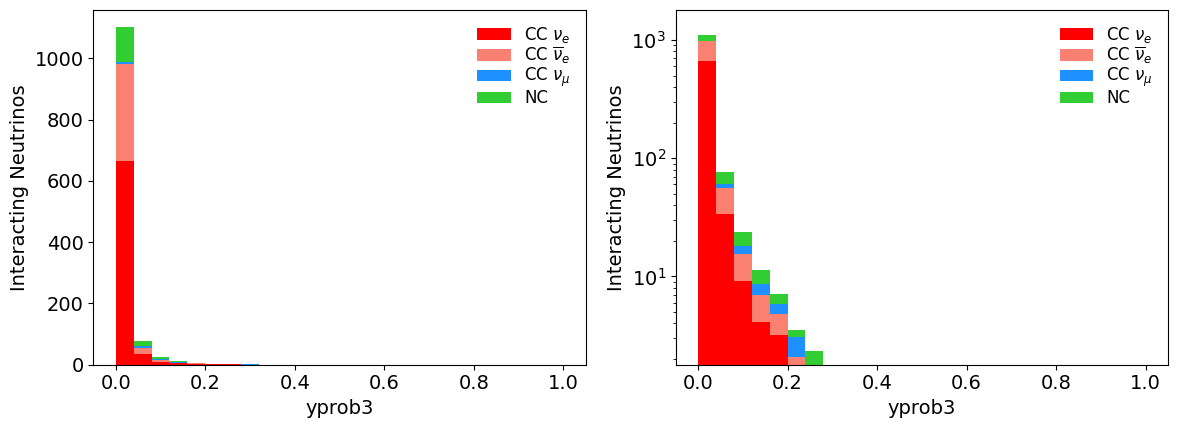

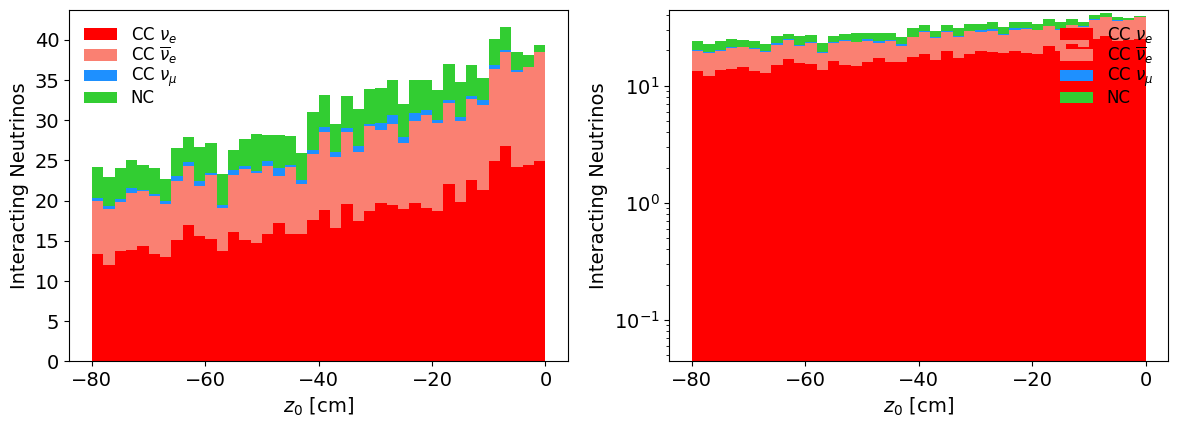

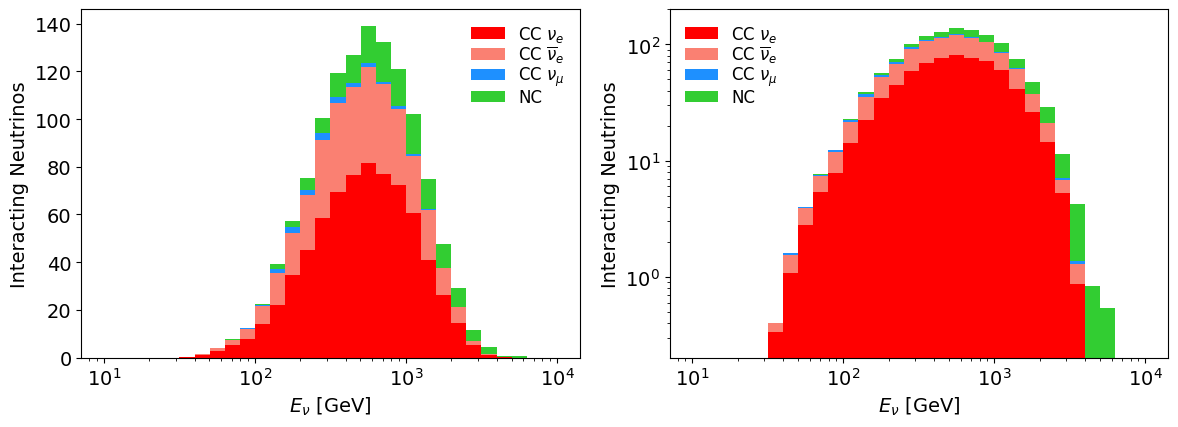

All events 1466.003954243466
nue, nuebar events (truth) 757.0025487972298 376.9303981555301
nue, nuebar events (pred) 817.3066409453967 412.4735447380109


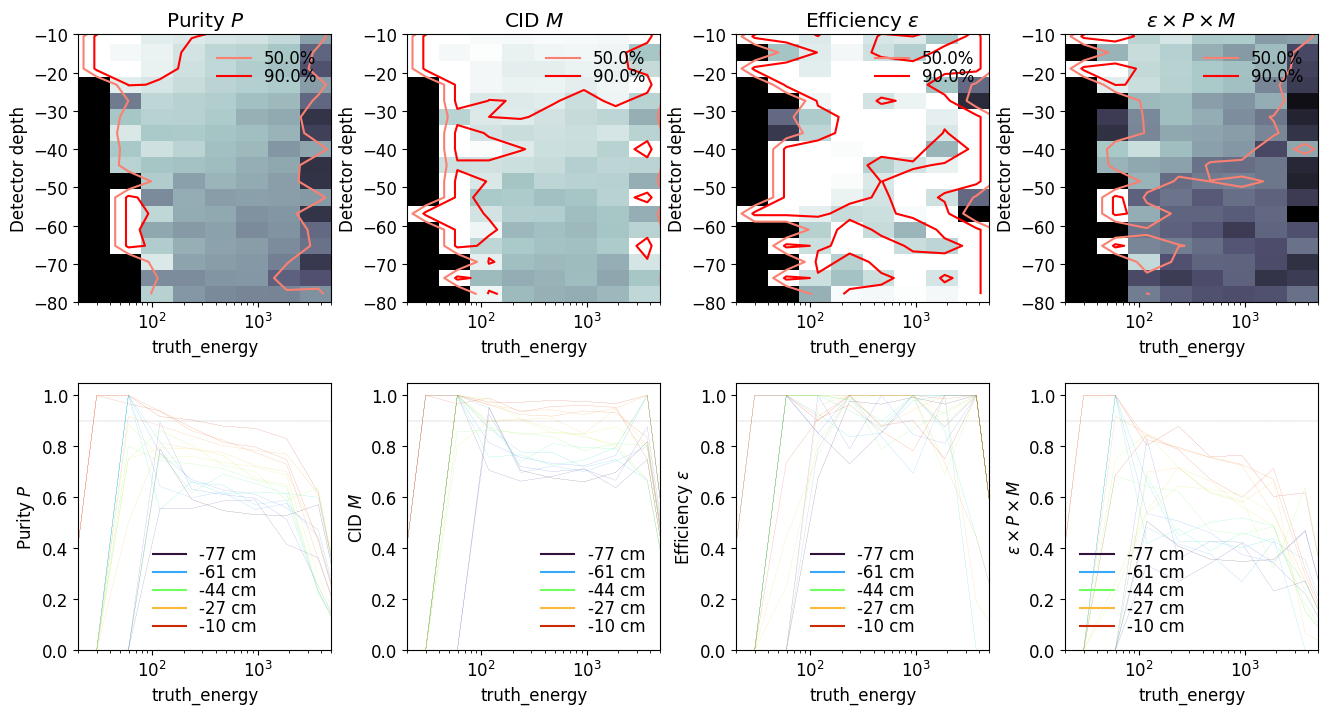

In [26]:
bdt_emu_cut,eff_emu_cut = BDTresults(data2bdt=df[df['e_mu']<e_mu_cut], uncutdata=df)

Note that choosing values for the `yprob*`, e.g. `bdt_emu_cut[bdt_emu_cut['yprob1']>0.05]`, will not necessarily improve the performance. The BDT automatically assigns some criteria for event selection when we call `pred_set`, and setting the `yprob*` would just replace that with our own selection, and the BDT already does a good job at setting the cuts.

Now restrict to the detector depth available in the current FASER location:

BDT results including all events


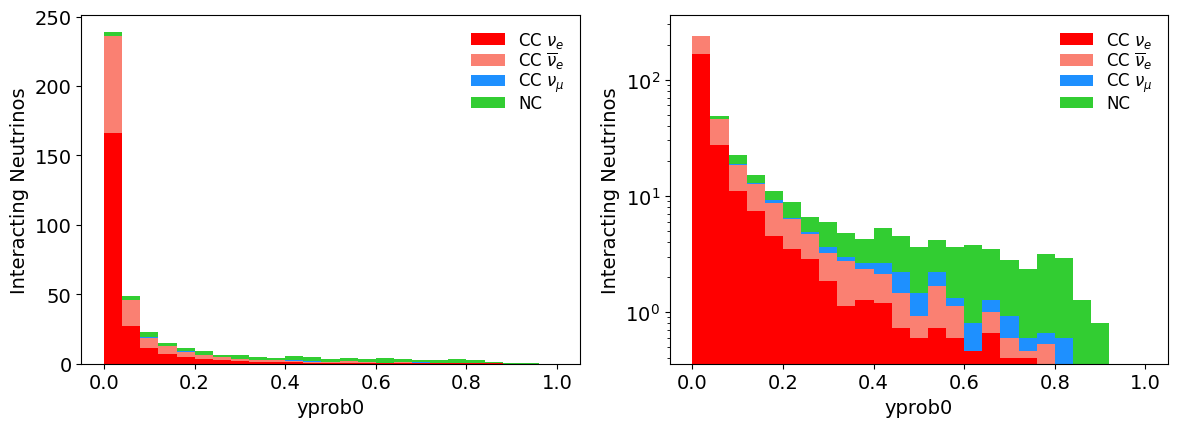

BDT results for events classified as signal


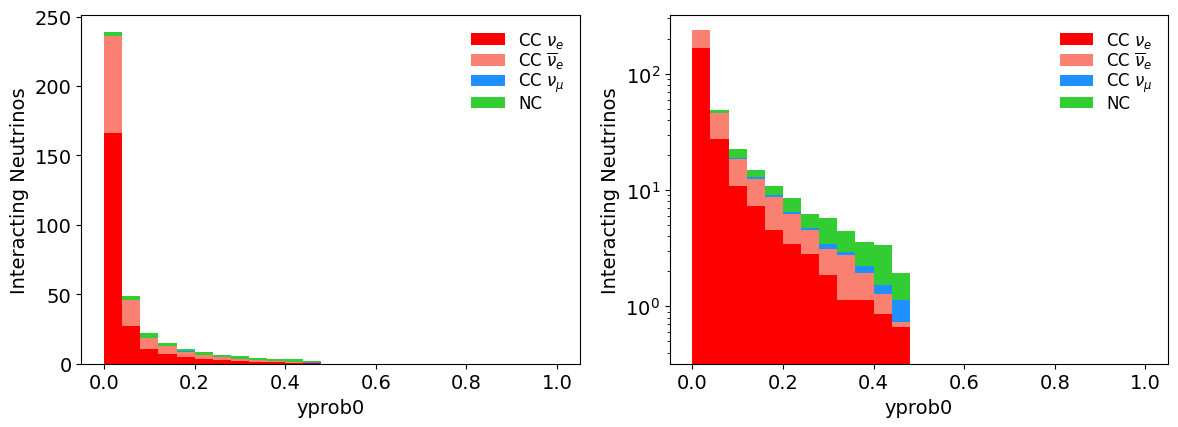

BDT results including all events


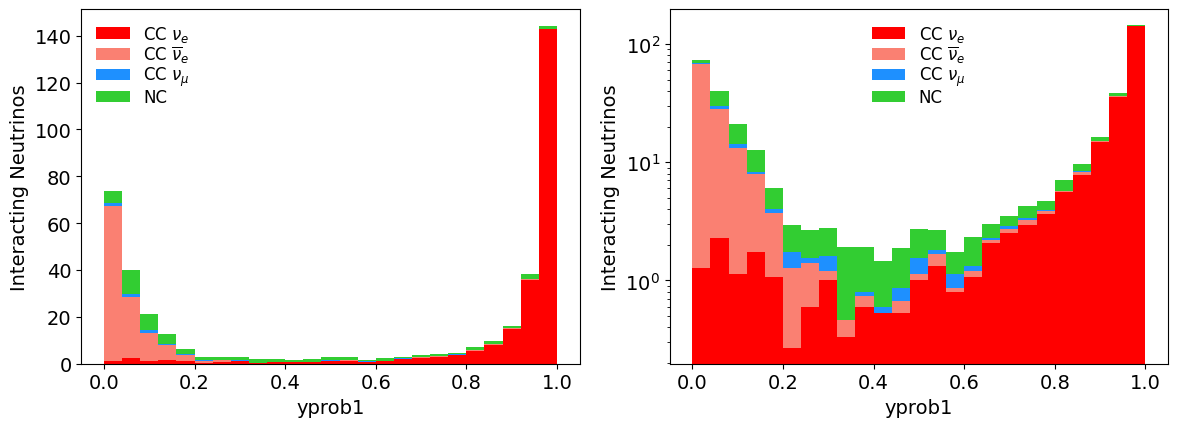

BDT results for events classified as signal


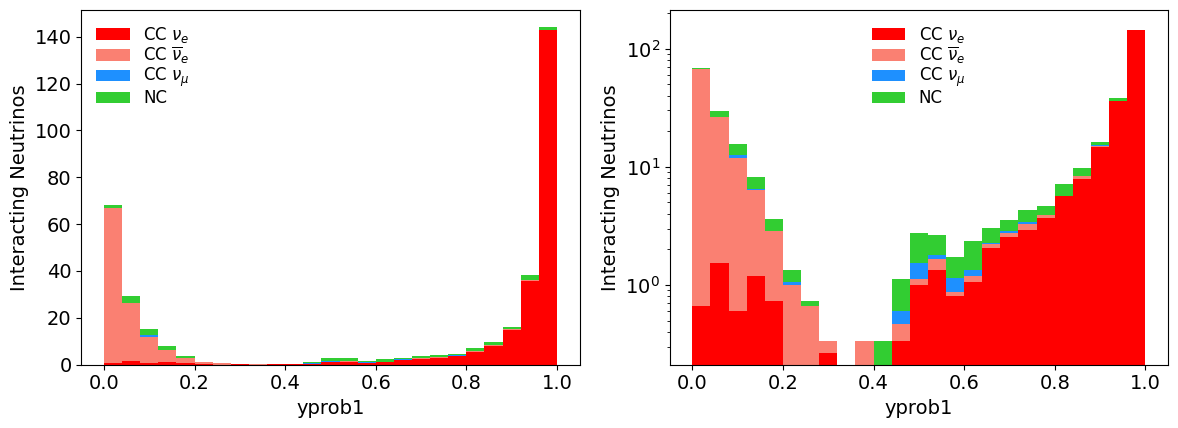

BDT results including all events


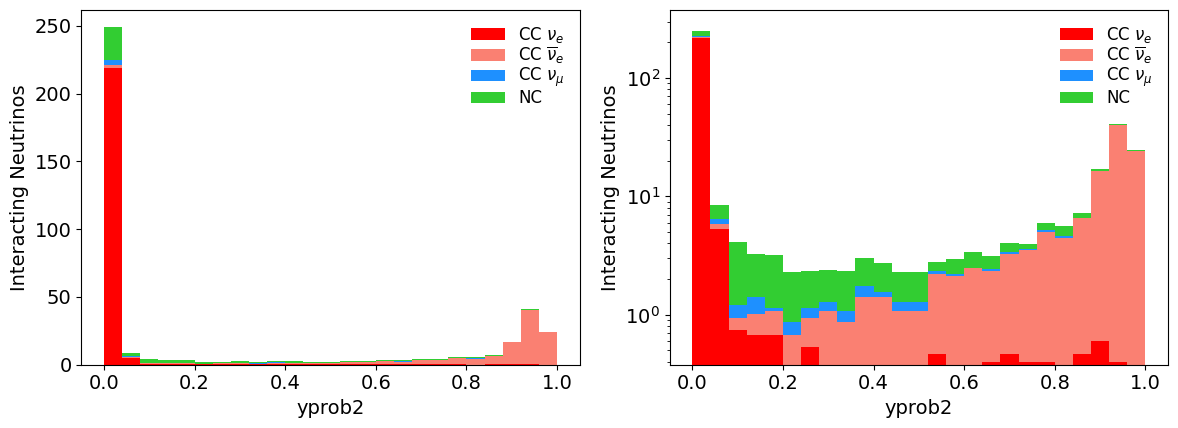

BDT results for events classified as signal


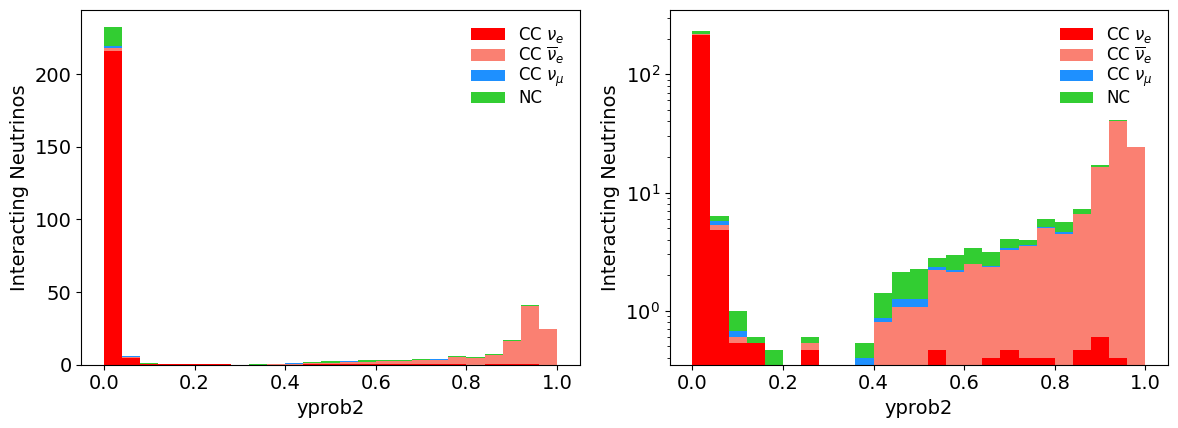

BDT results including all events


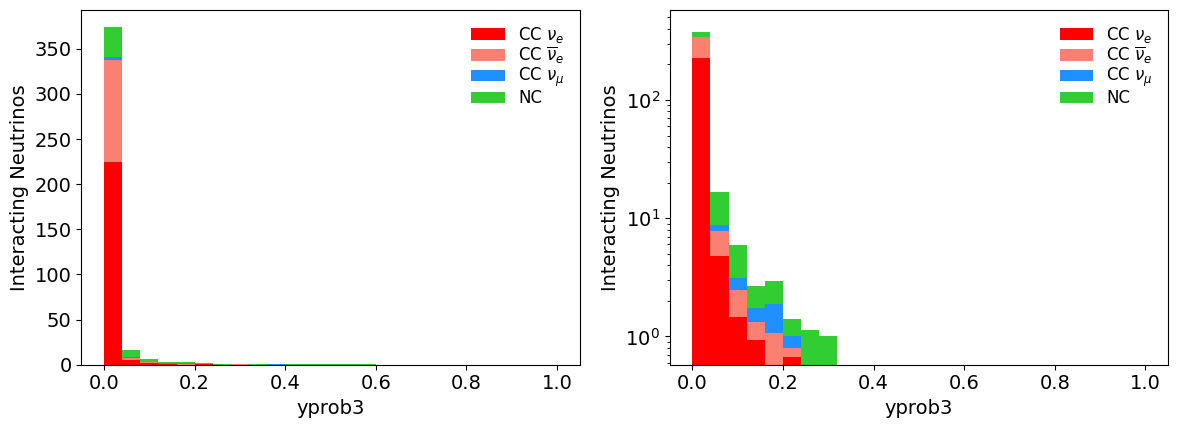

BDT results for events classified as signal


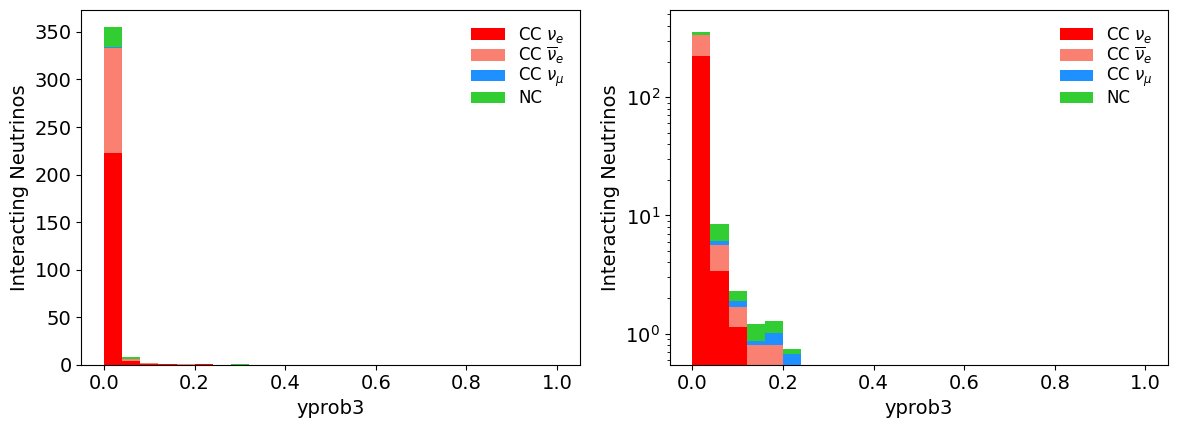

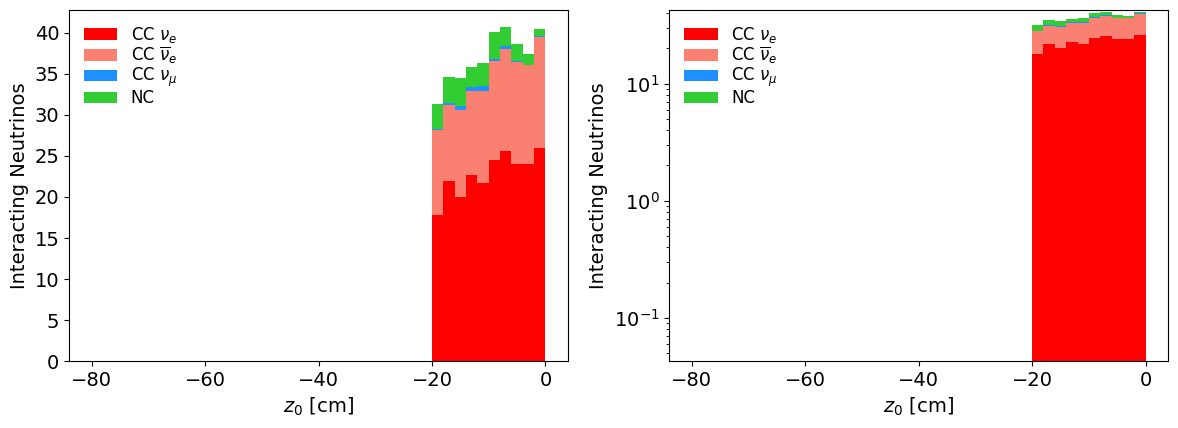

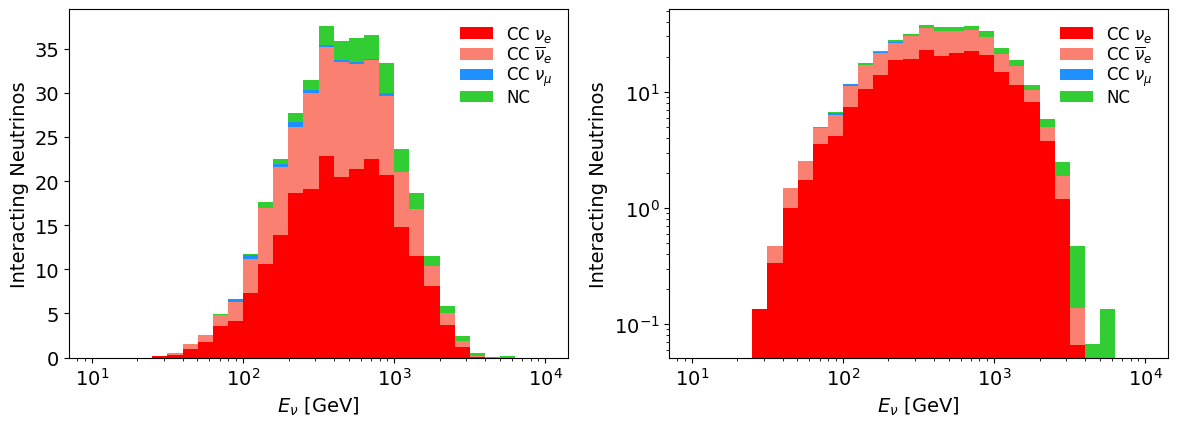

All events 409.3078648181837
nue, nuebar events (truth) 233.54196004994202 118.29401496940022
nue, nuebar events (pred) 242.02306918515652 127.76708536054032
In BDT results: nue 1076 , nuebar 514 , numu 14 , NC 113


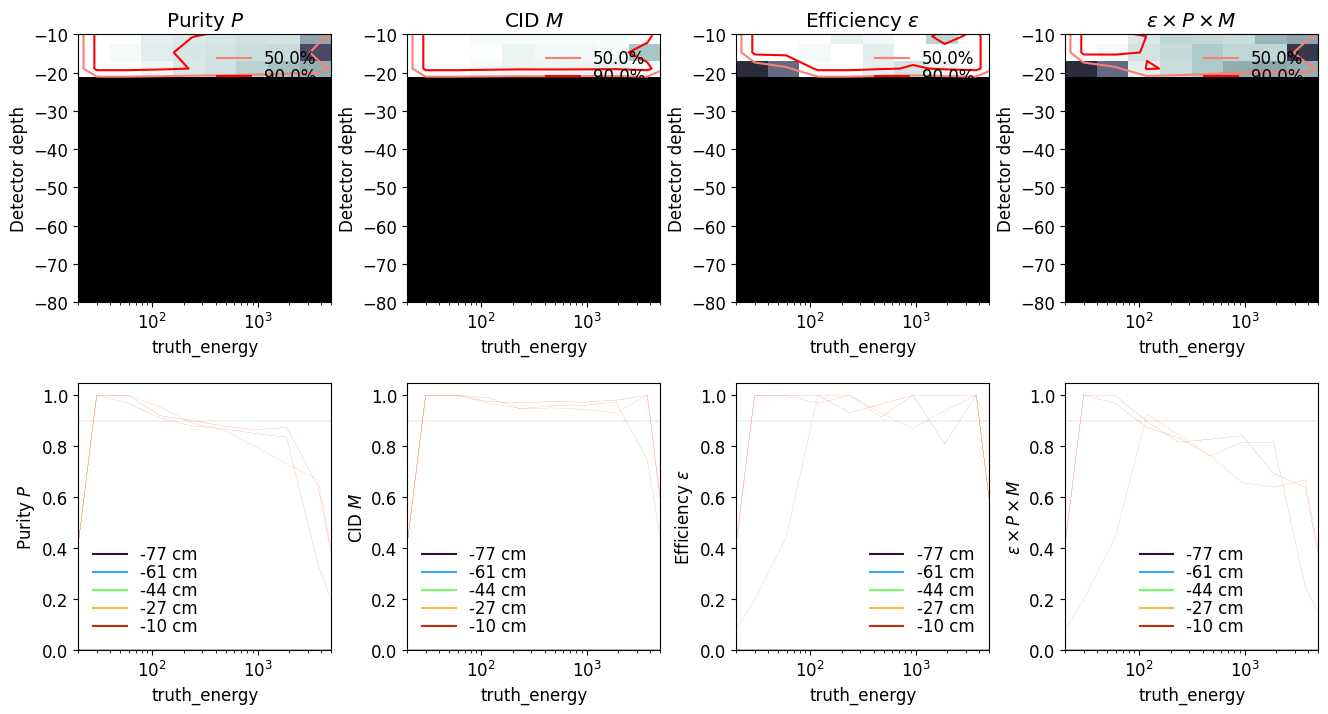

In [27]:
df_FASER = df[df['e_mu']<e_mu_cut]
df_FASER = df_FASER[df_FASER['z0']>z0cutFASER]
bdt_emu_cut_FASER,eff_emu_cut_FASER = BDTresults(data2bdt=df_FASER, uncutdata=df[df['z0']>z0cutFASER])

bdt_pred = bdt_emu_cut_FASER[bdt_emu_cut_FASER['pred_set'].isin(['nue','nuebar'])]
print('In BDT results: nue',   int(FPFscaling['nue'   ]*sum(list(bdt_pred[bdt_pred['set'].isin(['nue'   ])]['weight']))),\
                    ', nuebar',int(FPFscaling['nuebar']*sum(list(bdt_pred[bdt_pred['set'].isin(['nuebar'])]['weight']))),\
                    ', numu',  int(FPFscaling['numu'  ]*sum(list(bdt_pred[bdt_pred['set'].isin(['numu'  ])]['weight']))),\
                    ', NC',    int(FPFscaling['NC'    ]*sum(list(bdt_pred[bdt_pred['set'].isin(['NC'    ])]['weight']))))

In [28]:
def effPaperPlot(ipdicts,ebins):

    #Init figure
    matplotlib.rcParams.update({'font.size': 12})
    fig = plt.figure(figsize=(6,4))
    ax = plt.subplot(1,1,1)
    ecenters = np.multiply(0.5,np.add(ebins[:-1],ebins[1:]))

    #Plot
    labels=True  #Flag to ensure legend is only filled on the first iteration
    for i,key in enumerate(ipdicts):
        z = ipdicts[key]['z0']
        col = ipdicts[key]['col']
        ax.plot(ecenters,[ipdicts[key]['ipd']['pur'](E,z) for E in ecenters],color=col,linestyle='dashed',lw=1.3,\
                label=r'Purity $P$' if labels else None)
        ax.plot(ecenters,[ipdicts[key]['ipd']['eff'](E,z) for E in ecenters],color=col,linestyle='dashdot',lw=1.3,\
                label=r'Efficiency $\epsilon$' if labels else None)
        ax.plot(ecenters,[ipdicts[key]['ipd']['cid'](E,z) for E in ecenters],color=col,linestyle='dotted',\
                label=r'Charge ID $C$' if labels else None)
        ax.plot(ecenters,[ipdicts[key]['ipd']['tot'](E,z) for E in ecenters],color=col,linestyle='solid',lw=2.2,\
                label=r'$P \times \epsilon \times C$' if labels else None)
        #if i==0: ax.text(120,0.6,'20 cm detector')
        ax.text(700,0.50-0.04*(i+1),key,color=col)
        labels=False
    ax.set_xscale('log')
    ax.set_xlim(60.,1800.)
    ax.set_ylim(0.4,1.05)
    ax.set_xlabel(r'$E_\nu$ [GeV]')
    #ax.set_xlabel(r'$E_e$ [GeV]')
    ax.set_ylabel(r'Performance ratio')
    ax.legend(frameon=False,loc='center right')
    plt.subplots_adjust(left=0.10,right=0.97,bottom=0.13,top=0.98)    #Adjust margins to fit axis labels and titles
    savename = 'plots/'+eventstag+'_performance.pdf'
    plt.savefig(savename)
    print('Saving',savename)

Saving plots/events_performance.pdf


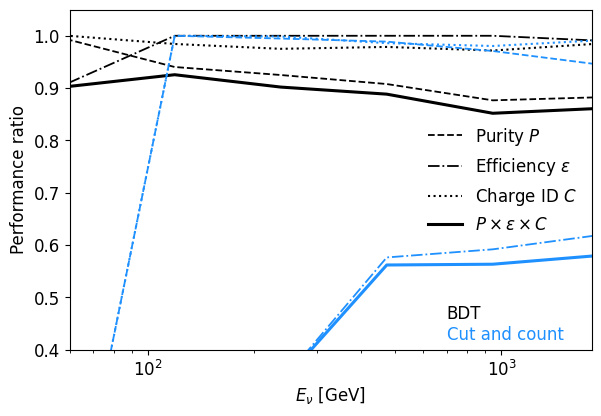

In [29]:
eff_CNC_FASER_cumul     = efficiency(data=df_CNC_FASER,      uncut=df_FASER, z0bins=np.linspace(z0cutFASER,1,20),plots=False,cumul=True)
eff_emu_cut_FASER_cumul = efficiency(data=bdt_emu_cut_FASER, uncut=df_FASER, z0bins=np.linspace(z0cutFASER,1,20),plots=False,cumul=True)
effPaperPlot(ipdicts={'BDT':          {'z0':-19, 'col':'black',      'ipd': eff_emu_cut_FASER_cumul},\
                      'Cut and count':{'z0':-19, 'col':'dodgerblue', 'ipd': eff_CNC_FASER_cumul}},\
             ebins=ebins_efficiency)

### Investigate optimal detector length

Investigate the optimal detector length by scanning over z0 values. 
The aim is to find the $z_0$ at which the number of high-$E$ electrons/positrons plateaus, ergo any additional detector length does not significantly increase the signal. Note that a clear peak is not necessarily expected. If there is a peak, it implies that after some $z_0$, the efficiency gets bad enough to counter the fact that more volume implies more interaction vertices. The efficiency does get worse for longer detectors, but the BDT seems to do a good job for high-$E$ $e^\pm$ also at longer detectors.

In [30]:
#Param
#  data       The data object to plot, e.g. the result of a bdt analysis
#  effdict    Dictionary of interpolation functions for efficiency
#  ebins      Energy bins
#  z0bins     Depth bins
#  edict      List of energies to be plotted and the colors to use for them
#  cdf        Plot cumulant function or not?

def Nevents_depth(data,effdict,ebins,z0bins,edict={200: 'black'}):
    
    # setup figure
    matplotlib.rcParams.update({'font.size': 12})
    matplotlib.rcParams['text.usetex'] = False
    Nrow,Ncol = 2,3
    fig = plt.figure(figsize=(6,4))
    xlabels = [r'$z_0$ [cm]', r'Detector length [cm]']
    titleadd = [r'', r', cumulative']

    #Energy and z-binning related quantities
    eobs = 'truth_energy'  #'e_e'
    etol = 1  #Tolerance: look for energies +- tol from the requested value
    e_e_cut = 100.  #Require events to have at least a 100 GeV electron
    z0centers=np.divide(np.add(z0bins[1:],z0bins[:-1]),2)
    z0centersPlus = np.multiply(-1,z0centers)
    z0binsInv = np.abs(z0bins)[::-1]
    
    #Normalize to number of events in paper to avoid confusion w/ different event generators etc
    setstr = 'pred_set' if 'pred_set' in list(data.keys()) else 'set'
    data_N = data[data[setstr].isin(['nue','nuebar'])]
    data_N = data_N[data_N['z0']>-20]
    norm = 32./sum(data_N['weight'])  #FASER-PS is 20 cm and has 21 (11) nue (nuebar) events

    cidavg=[]  #Store average of the CID performance metric for the two energies - they are similar so no need to plot twice
    for n,ene in enumerate(edict):
        #Scan over detector lengths
        Nnue,Nnub = [],[]  #Init arrays to store results to
        for i in range(len(z0bins)-1):
            
            #Depth
            dataz0 = data[data['z0']>z0bins[i]]
            dataz0 = data[data['z0']<z0bins[i+1]]
            
            #Requested energy
            dataz0 = dataz0[dataz0[eobs]>ene - etol]
            dataz0 = dataz0[dataz0[eobs]<ene + etol]

            #Require high-E electron?
            dataz0 = dataz0[dataz0['e_e']>e_e_cut]  #N.B. not eobs here
            
            #Signal events
            dataz0_nue = dataz0[dataz0[setstr].isin(['nue'])]
            dataz0_nub = dataz0[dataz0[setstr].isin(['nuebar'])]
            
            #Evaluate efficiencies
            effnue = effdict['tot'](ene,z0centers[i])
            effnub = effdict['tot'](ene,z0centers[i])

            #Find total numbers of events for a detector of given length
            hnue,_ = np.histogram(dataz0_nue[eobs],bins=ebins,weights=np.multiply(dataz0_nue['weight'],effnue))
            hnub,_ = np.histogram(dataz0_nub[eobs],bins=ebins,weights=np.multiply(dataz0_nub['weight'],effnub))
            
            #Normalization, add to event number lists
            Nnue.append(norm*sum(hnue))
            Nnub.append(norm*sum(hnub))
            
        #Plot number of events
        ax = plt.subplot(1,1,1)
        color = edict[ene]
        ax.hist(z0centersPlus,bins=z0binsInv,weights=Nnue,histtype='step',color=color,linestyle='solid')
        ax.hist(z0centersPlus,bins=z0binsInv,weights=Nnub,histtype='step',color=color,linestyle='dotted',linewidth=1.7)
        
        #Average of performance metrics
        if n==0: cidavg = np.array([effdict['cid'](ene,-z0c) for z0c in z0centersPlus])
        else: cidavg = np.multiply(0.5, np.add(cidavg, np.array([effdict['cid'](ene,-z0c) for z0c in z0centersPlus])))
    
    #Plot performance metrics
    ax2 = ax.twinx()
    coarsef = 3  #Average over this many neighboring bins, the plot will be smoother with coarser binning
    z0centersPlusCoarse = [1./coarsef*sum([z0centersPlus[coarsef*i+j] for j in range(coarsef)]) for i in range(int(len(cidavg)/coarsef))]
    cidavgCoarse = [1./coarsef*sum([cidavg[coarsef*i+j] for j in range(coarsef)]) for i in range(int(len(cidavg)/coarsef))]
    ax2.plot(z0centersPlusCoarse[1:],cidavgCoarse[1:],color='black',linestyle='dashed',lw=1.7)

    #Neutrino energy labels
    try:
        ene = list(edict.keys())[0]
        ax.text(5,0.2,r'$E_\nu=$'+str(ene)+r' GeV',color=edict[ene],rotation=-30)
        ene = list(edict.keys())[1]
        ax.text(9,0.9,r'$E_\nu=$'+str(ene)+r' GeV',color=edict[ene],rotation=-40)
    except: print('WARNING could not write neutrino energy labels on plot, check e.g. indices vs array lengths')
    
    #For legend
    ax.plot([-1,-1],color='black',linestyle='dashed',linewidth=1.7,label=r'Charge ID $C$')
    ax.plot([-1,-1],color='black',linestyle='solid', linewidth=1.0,label=r'$\nu_e$'      )
    ax.plot([-1,-1],color='black',linestyle='dotted',linewidth=1.7,label=r'$\bar{\nu}_e$')
    
    #Style setup
    ax.text(0.46*abs(z0bins[0]),2.75,r'Events with $E>'+str(e_e_cut)+'$ GeV $e^\pm$',color='black')
    ax.legend(frameon=False,loc='center right')
    ax.set_xlim(3,abs(z0min*0.97))
    ax.set_ylim(0,2.9)
    ax.set_xlabel('Detector depth [cm]')
    ax.set_ylabel(r'#Events passing BDT selection')
    ax2.set_ylabel(r'BDT charge identification success rate')
    plt.subplots_adjust(left=0.11,right=0.88,bottom=0.13,top=0.98)    #Adjust margins to fit axis labels and titles
    savename = 'plots/Nevents_depth.pdf'
    plt.savefig(savename)
    print('Saving',savename)

Saving plots/Nevents_depth.pdf


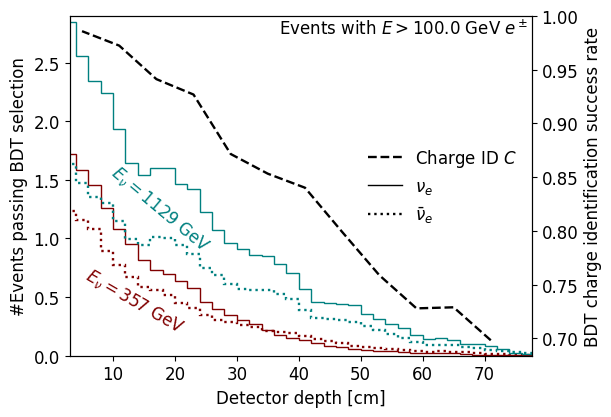

In [31]:
Nevents_depth(data=bdt_emu_cut,\
              effdict=eff_emu_cut,\
              ebins=ebins_efficiency,\
              z0bins=np.linspace(z0min,-0,abs(int(z0min/2))+1),\
              edict={357:'maroon',1129:'teal'})

### Neutrino energy reconstruction

User the results of the previous nue event classifier as the input data for a regression classifier, used for retrieving the incoming neutrino's truth energy using a regression classifier.

In [32]:
def regressionEnu(data):
    
    #Input features. Could also pass the information of whether the event was classified as nue/nuebar ('ypred'), but doesn't seem useful
    features = ['e_em', 'e_ch', 'e_tot', 'z0', 'e_e', 'e_mu', 'lep_pid', 'chEM', 'lep_theta', 'em_theta_std', 'em_theta_max']#, 'ypred']

    X, y, weights = data[features], data['truth_energy'], data['weight']
    
    #Define preprocessing: log-transform and scaling
    test_size=0.75
    X_train, X_test, y_train, y_test, weights_train, weights_test = train_test_split(
        X, y, weights, test_size=test_size, random_state=137
    )
    
    X_train.reset_index(drop=True, inplace=True)
    X_test.reset_index(drop=True, inplace=True)
    y_train.reset_index(drop=True, inplace=True)
    y_test.reset_index(drop=True, inplace=True)
    weights_train.reset_index(drop=True, inplace=True)
    weights_test.reset_index(drop=True, inplace=True)
    
    #Train the BDT for regression
    #The key parameters are n_estimators (number of trees) and learning_rate (eta).
    bdt_regressor = GradientBoostingRegressor(
        n_estimators=100,      # Number of boosting stages
        learning_rate=0.1,     # Shrinkage
        max_depth=3,           # Individual tree complexity
        loss='squared_error',  # Standard MSE loss for regression
        random_state=137
    )
    bdt_regressor.fit(X_train, y_train)

    #Make predictions
    y_pred = bdt_regressor.predict(X_test)

    #Return dataframe
    processed = X_test.copy()
    processed['truth_energy'] = np.array(y_test)
    processed['reco_energy' ] = np.array(y_pred)
    if 'ypred' in features: processed['pred_set'] = [tagAsStr(y) for y in X_test['ypred']]  #Predicted set
    processed['weight'] = weights_test / test_size

    return processed    
    
    
def plotEnuReco(bdt):    
    #Setup figure
    matplotlib.rcParams.update({'font.size': 14})
    matplotlib.rcParams['text.usetex'] = False
    fig = plt.figure(figsize=(7,5))
    ax1 = plt.subplot(1,1,1)   
    
    #plot scatterplot of predicted neutrino energies vs truth energy
    ax1.plot(bdt['truth_energy'],bdt['reco_energy'],linewidth=0,marker='.',markersize=0.5)
    ax1.set_xscale("log")
    ax1.set_yscale("log")
    ax1.set_xlabel(r'MC truth $E_\nu$')
    ax1.set_ylabel(r'Reconstructed $E_\nu$')


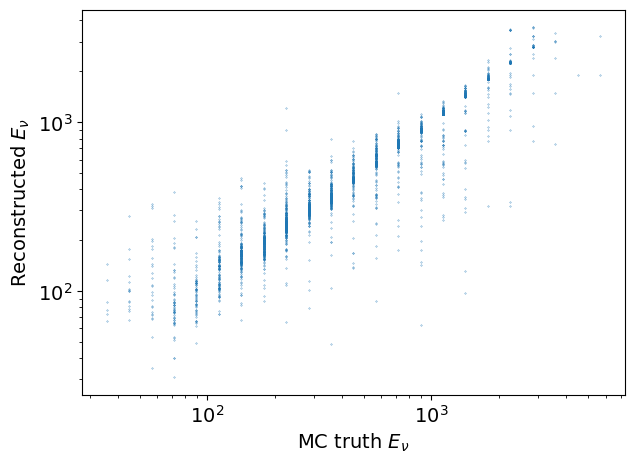

In [33]:
regressionbdt_FASER = bdt_emu_cut[bdt_emu_cut['z0']>z0cutFASER]
regressionbdt_FASER = regressionbdt_FASER[regressionbdt_FASER['pred_set'].isin(['nue','nuebar'])]
bdt_enu_reco_FASER = regressionEnu(data=regressionbdt_FASER)
plotEnuReco(bdt_enu_reco_FASER)

Here we see that the for each true energy value, there is some (presumably) Gaussian-like distribution spreading out the reconstructed energies. The width of the peak seems to be hundreds of GeV. 
Likely some bin migrations will occur in below-TeV events, but we don't expect to use a fine binning for the plastic scintillator.
Another effect is that the peak of the distribution is not exactly at the value of the corresponding truth energy, but this is expected and the experimentalists will apply some function to map the systematically smaller charged lepton energies to neutrino energies, and a proper study with unfolding etc is beyond our scope here.
The main point is that we probably don't need to introduce smearing or some loss function to the CID analysis due to energy reconstruction effects. Now let's estimate the smearing in energy reconstruction by finding the standard deviation of the $E_\nu$ reconstructed by the BDT vs MC truth, i.e. plot vertical slices of the above.

In [34]:
def Esmearing(bdt,ebins=ebins_default,effip=None,Ldet=z0min):
    
    #get energies
    energies, _, _= np.loadtxt("fluxes/flux_FASER2_12.txt").T
    ecenters = (ebins[:-1] + ebins[1:]) / 2

    #initialize figure
    matplotlib.rcParams.update({'font.size': 6})
    matplotlib.rcParams['text.usetex'] = False
    fig = plt.figure(figsize=(12,14.4))
    ncol = 5

    std=[]  #For storing standard deviation results
    for i,etrue in enumerate(energies):

        #Init axes for subplot
        ax = plt.subplot(int(np.ceil(len(energies)/5)), 5, i+1)  #Arguments are nrows, ncols, index (starting at 1 not 0)   
        
        #Fetch reconstructed energies and weights for events corresponding to a given truth energy
        bdt_efix = bdt[bdt['truth_energy']==etrue]        
        counts,_,_ = ax.hist(bdt_efix['reco_energy'],bins=ebins,weights=bdt_efix['weight'],label=r'$E_\nu=$'+str(etrue)+r' GeV')

        #Find mean and standard deviation
        mean   = np.sum(np.multiply(counts,ecenters))/np.sum(counts)
        std.append(np.sqrt(np.sum(np.multiply(counts, np.power(np.subtract(ecenters,mean),2))) / np.sum(counts)))
        
        #Setup first set of figures: the E_e smear at each E_nu
        ax.set_xscale("log")
        ax.set_xlabel(r'$E_e$')
        #ax.set_ylabel(r"Interacting Neutrinos")
        ax.legend(frameon=False, labelspacing=0, fontsize=5)

    #Setup the second figure: standard deviation vs truth energy and efficiency vs E_e
    matplotlib.rcParams.update({'font.size': 14})
    matplotlib.rcParams['text.usetex'] = False
    fig = plt.figure(figsize=(6,4))
    ax = plt.subplot(1,1,1)   
    
    #Plot standard deviation vs truth energy
    ax.plot(energies,np.multiply(100,np.divide(std,energies)))  #(relative std error)*100 => %
    
    #Finalize plot style setup
    #ax.legend(frameon=False, labelspacing=0, fontsize=12)
    ax.set_ylabel(r'Std.dev./$E_\nu$ [%]')
    ax.set_xlabel(r'$E_\nu^{\rm True}$ [GeV]')
    ax.set_xlim(200,3000)
    ax.set_ylim(0,100)
    ax.set_xscale("log")

/tmp/ipykernel_14601/504391717.py:24: RuntimeWarning: invalid value encountered in scalar divide
  mean   = np.sum(np.multiply(counts,ecenters))/np.sum(counts)


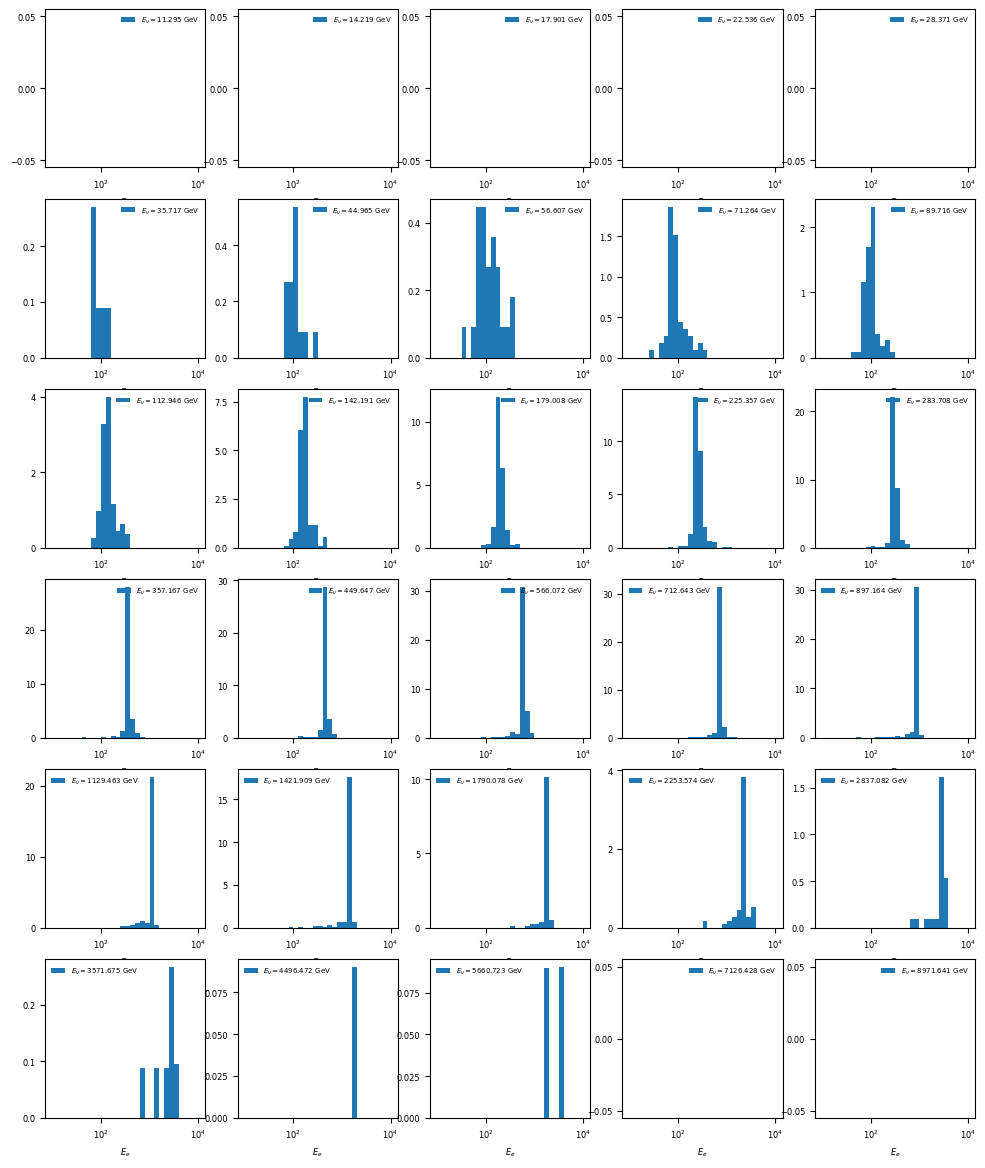

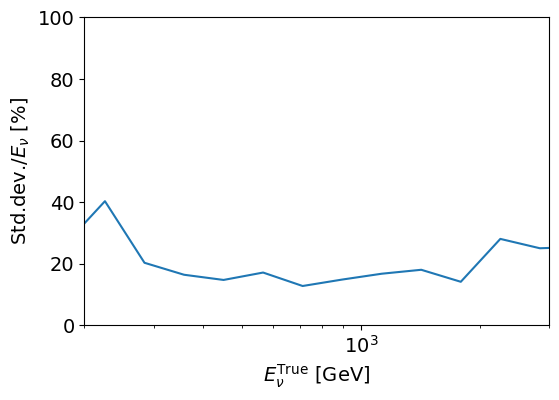

In [35]:
Esmearing(bdt=bdt_enu_reco_FASER)